In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, f_oneway, chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.ticker as mticker
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['grid.linestyle']    = '--'

COLORS = ['#2E75B6','#ED7D31','#70AD47','#FFC000','#9B59B6',
          '#E74C3C','#1ABC9C','#F39C12','#2980B9','#27AE60',
          '#8E44AD','#D35400','#16A085','#C0392B','#2C3E50',
          '#7F8C8D','#F1C40F']

print(' All libraries loaded!')
print('   pandas :', pd.__version__)
print('   numpy  :', np.__version__)




 All libraries loaded!
   pandas : 2.3.3
   numpy  : 2.3.5


# step 1
## load data

In [3]:
# ── LOAD BOTH FILES ──────────────────────────────────────
PATH_SALES = r"C:\Users\srika\Downloads\FINAL DATA\pd_sales_final.xlsx"
PATH_TXN   = r"C:\Users\srika\Downloads\FINAL DATA\TS_sales_data.xlsx"
# ─────────────────────────────────────────────────────────

df     = pd.read_excel(PATH_SALES, sheet_name='pd_sales', engine='openpyxl')
df_txn = pd.read_excel(PATH_TXN, engine='openpyxl')

# Merge bill-level info into product-level
df = df.merge(
    df_txn[['TS_NO','TS_NETTVAL','TS_GROSSVAL','TS_ROUNDOFF']],
    on='TS_NO', how='left'
)

print(f'✅ Dataset 1 loaded  : {len(df):,} rows')
print(f'✅ Dataset 2 loaded  : {len(df_txn):,} rows')
print(f'✅ Merged shape      : {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')

✅ Dataset 1 loaded  : 43,341 rows
✅ Dataset 2 loaded  : 8,345 rows
✅ Merged shape      : (43341, 25)

Columns: ['TS_RECNO', 'TS_NO', 'TS_BILL', 'TS_DATE', 'TS_NAME', 'Category', 'TS_TXNTYPE', 'TS_CUSTOMER', 'TS_PFX', 'MRP', 'selling_price', 'Discount', 'Dis_per', 'quantity', 'profit_from_sales', 'total', 'gross_total', 'roundoff', 'net_total', 'Est_Pur_Price', 'Profit_per_pd', 'Profit Margin', 'TS_NETTVAL', 'TS_GROSSVAL', 'TS_ROUNDOFF']


In [4]:
df.columns



Index(['TS_RECNO', 'TS_NO', 'TS_BILL', 'TS_DATE', 'TS_NAME', 'Category',
       'TS_TXNTYPE', 'TS_CUSTOMER', 'TS_PFX', 'MRP', 'selling_price',
       'Discount', 'Dis_per', 'quantity', 'profit_from_sales', 'total',
       'gross_total', 'roundoff', 'net_total', 'Est_Pur_Price',
       'Profit_per_pd', 'Profit Margin', 'TS_NETTVAL', 'TS_GROSSVAL',
       'TS_ROUNDOFF'],
      dtype='object')

In [5]:
# SALES DATA 
df.describe()


,TS_RECNO,TS_NO,TS_DATE,MRP,selling_price,Discount,Dis_per,quantity,profit_from_sales,total,gross_total,roundoff,net_total,Est_Pur_Price,Profit_per_pd,Profit Margin,TS_NETTVAL,TS_GROSSVAL,TS_ROUNDOFF
count,43341.000000,43341.000000,43341,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000,43341.00000,43341.000000,43341.000000,43341.000000,43341.000000,43341.000000
mean,21671.000000,12749.561478,2025-12-05 07:24:52.877414144,45.568598,41.885467,3.683131,0.070504,1.885420,5.762011,50.320898,700.629769,0.047736,699.957615,37.19839,4.687076,0.126598,699.957615,700.629769,0.047736
min,1.000000,8505.000000,2025-09-01 00:00:00,0.980000,0.980000,0.000000,0.000000,1.000000,0.080000,1.000000,4.000000,-0.500000,4.000000,0.72000,0.080000,0.022000,4.000000,4.000000,-0.500000
25%,10836.000000,10657.000000,2025-10-19 00:00:00,10.000000,10.000000,0.000000,0.000000,1.000000,1.780000,15.000000,140.800000,-0.070000,141.000000,8.99000,1.200000,0.091509,141.000000,140.800000,-0.070000
50%,21671.000000,12802.000000,2025-12-05 00:00:00,25.000000,22.000000,0.000000,0.000000,1.000000,3.380000,28.000000,323.600000,0.000000,324.000000,19.62000,2.520000,0.123333,324.000000,323.600000,0.000000
75%,32506.000000,14758.000000,2026-01-18 00:00:00,48.000000,45.000000,2.000000,0.030000,2.000000,6.150000,50.000000,841.200000,0.200000,841.000000,39.05000,4.990000,0.160000,841.000000,841.200000,0.200000
max,43341.000000,16854.000000,2026-03-10 00:00:00,1900.000000,1900.000000,355.000000,0.964286,150.000000,420.300000,3800.000000,10960.100000,0.500000,10960.000000,1778.40000,237.920000,0.280000,10960.000000,10960.100000,0.500000
std,12511.613345,2398.115541,NaN,106.128065,103.509186,13.115476,0.161994,3.323757,12.245838,110.619780,1005.185517,0.240651,1004.854820,93.38704,11.469343,0.047194,1004.854820,1005.185517,0.240651


In [6]:
# TRANSACTION DATA
df_txn.describe()


,TS_RECNO,TS_NO,TS_DATE,TS_ROUNDOFF,TS_NETTVAL,TS_GROSSVAL
count,8345.000000,8345.000000,8345,8345.000000,8345.000000,8345.000000
mean,4173.000000,12679.376273,2025-12-03 16:09:05.284601600,0.055963,261.988736,262.131128
min,1.000000,8505.000000,2025-09-01 00:00:00,-0.500000,4.000000,4.000000
25%,2087.000000,10591.000000,2025-10-18 00:00:00,0.000000,60.000000,60.000000
50%,4173.000000,12680.000000,2025-12-03 00:00:00,0.000000,120.000000,120.000000
75%,6259.000000,14767.000000,2026-01-18 00:00:00,0.100000,256.000000,256.000000
max,8345.000000,16854.000000,2026-03-10 00:00:00,0.500000,10960.000000,10960.100000
std,2409.138331,2410.939947,NaN,0.197830,466.766605,467.072154


In [7]:
df

,TS_RECNO,TS_NO,TS_BILL,TS_DATE,TS_NAME,Category,TS_TXNTYPE,TS_CUSTOMER,TS_PFX,MRP,...,total,gross_total,roundoff,net_total,Est_Pur_Price,Profit_per_pd,Profit Margin,TS_NETTVAL,TS_GROSSVAL,TS_ROUNDOFF
0,1,8505,A/8505,2025-09-01,CLOSE UP TOOTH PASTE 21G,Oral Care,Invoice,Cash Sales,A,10.0,...,9.7,173.7,0.3,174,8.54,1.16,0.119588,174,173.7,0.3
1,2,8505,A/8505,2025-09-01,PARACHUTE 25ML,Hair Care,Invoice,Cash Sales,A,10.0,...,10.0,173.7,0.3,174,8.54,1.46,0.146000,174,173.7,0.3
2,3,8505,A/8505,2025-09-01,ORAL B MEDIUM CHARCOAL,Oral Care,Invoice,Cash Sales,A,40.0,...,24.0,173.7,0.3,174,21.15,2.85,0.118750,174,173.7,0.3
3,4,8505,A/8505,2025-09-01,ORAL -B,Oral Care,Invoice,Cash Sales,A,35.0,...,19.0,173.7,0.3,174,16.95,2.05,0.107895,174,173.7,0.3
4,5,8505,A/8505,2025-09-01,BADAM 50G,Dry Fruits & Nuts,Invoice,Cash Sales,A,58.0,...,44.0,173.7,0.3,174,38.47,5.53,0.125682,174,173.7,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,43337,16854,A/16854,2026-03-10,RIN REFRESH ROSE 500G,Home Care,Invoice,UPI,A,61.0,...,61.0,279.7,0.3,280,57.06,3.94,0.064590,280,279.7,0.3
43337,43338,16854,A/16854,2026-03-10,KADALA P VS 250G,Pulses & Dal,Invoice,UPI,A,24.0,...,24.0,279.7,0.3,280,22.69,1.31,0.054583,280,279.7,0.3
43338,43339,16854,A/16854,2026-03-10,VENTHIYM 100G,Spices & Masalas,Invoice,UPI,A,22.0,...,12.0,279.7,0.3,280,10.05,1.95,0.162500,280,279.7,0.3
43339,43340,16854,A/16854,2026-03-10,MILAGU 100G,Spices & Masalas,Invoice,UPI,A,95.0,...,95.0,279.7,0.3,280,86.16,8.84,0.093053,280,279.7,0.3


## pd_sales data cleaning

In [8]:
# ── RENAME COLUMNS ───────────────────────────────────────
df.rename(columns={
    'TS_RECNO'         : 'RecordNo',
    'TS_NO'            : 'BillNo',
    'TS_BILL'          : 'BillID',
    'TS_DATE'          : 'Date',
    'TS_NAME'          : 'ProductName',
    'TS_TXNTYPE'       : 'TxnType',
    'TS_CUSTOMER'      : 'CustomerType',
    'TS_PFX'           : 'Prefix',
    'selling_price'    : 'SellingPrice',
    'Dis_per'          : 'DiscountPct',
    'quantity'         : 'Quantity',
    'profit_from_sales': 'ProfitAmt',
    'total'            : 'SalesValue',
    'gross_total'      : 'GrossTotal',
    'roundoff'         : 'Roundoff',
    'net_total'        : 'NetTotal',
    'Est_Pur_Price'    : 'PurchasePrice',
    'Profit_per_pd'    : 'ProfitPerUnit',
    'Profit Margin'    : 'ProfitMarginPct',
    'TS_NETTVAL'       : 'BillNetVal',
    'TS_GROSSVAL'      : 'BillGrossVal',
    'TS_ROUNDOFF'      : 'BillRoundoff'
}, inplace=True)
# ── FIX DATA TYPES ───────────────────────────────────────
df['Date']            = pd.to_datetime(df['Date'])
df['MonthName']       = df['Date'].dt.strftime('%b %Y')
df['DayOfWeek']       = df['Date'].dt.day_name()

df



,RecordNo,BillNo,BillID,Date,ProductName,Category,TxnType,CustomerType,Prefix,MRP,...,Roundoff,NetTotal,PurchasePrice,ProfitPerUnit,ProfitMarginPct,BillNetVal,BillGrossVal,BillRoundoff,MonthName,DayOfWeek
0,1,8505,A/8505,2025-09-01,CLOSE UP TOOTH PASTE 21G,Oral Care,Invoice,Cash Sales,A,10.0,...,0.3,174,8.54,1.16,0.119588,174,173.7,0.3,Sep 2025,Monday
1,2,8505,A/8505,2025-09-01,PARACHUTE 25ML,Hair Care,Invoice,Cash Sales,A,10.0,...,0.3,174,8.54,1.46,0.146000,174,173.7,0.3,Sep 2025,Monday
2,3,8505,A/8505,2025-09-01,ORAL B MEDIUM CHARCOAL,Oral Care,Invoice,Cash Sales,A,40.0,...,0.3,174,21.15,2.85,0.118750,174,173.7,0.3,Sep 2025,Monday
3,4,8505,A/8505,2025-09-01,ORAL -B,Oral Care,Invoice,Cash Sales,A,35.0,...,0.3,174,16.95,2.05,0.107895,174,173.7,0.3,Sep 2025,Monday
4,5,8505,A/8505,2025-09-01,BADAM 50G,Dry Fruits & Nuts,Invoice,Cash Sales,A,58.0,...,0.3,174,38.47,5.53,0.125682,174,173.7,0.3,Sep 2025,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,43337,16854,A/16854,2026-03-10,RIN REFRESH ROSE 500G,Home Care,Invoice,UPI,A,61.0,...,0.3,280,57.06,3.94,0.064590,280,279.7,0.3,Mar 2026,Tuesday
43337,43338,16854,A/16854,2026-03-10,KADALA P VS 250G,Pulses & Dal,Invoice,UPI,A,24.0,...,0.3,280,22.69,1.31,0.054583,280,279.7,0.3,Mar 2026,Tuesday
43338,43339,16854,A/16854,2026-03-10,VENTHIYM 100G,Spices & Masalas,Invoice,UPI,A,22.0,...,0.3,280,10.05,1.95,0.162500,280,279.7,0.3,Mar 2026,Tuesday
43339,43340,16854,A/16854,2026-03-10,MILAGU 100G,Spices & Masalas,Invoice,UPI,A,95.0,...,0.3,280,86.16,8.84,0.093053,280,279.7,0.3,Mar 2026,Tuesday


In [9]:
# Fix decimal → percentage
df['DiscountPct']     = (df['DiscountPct']     * 100).round(2)
df['ProfitMarginPct'] = (df['ProfitMarginPct'] *100).round(2)

df

,RecordNo,BillNo,BillID,Date,ProductName,Category,TxnType,CustomerType,Prefix,MRP,...,Roundoff,NetTotal,PurchasePrice,ProfitPerUnit,ProfitMarginPct,BillNetVal,BillGrossVal,BillRoundoff,MonthName,DayOfWeek
0,1,8505,A/8505,2025-09-01,CLOSE UP TOOTH PASTE 21G,Oral Care,Invoice,Cash Sales,A,10.0,...,0.3,174,8.54,1.16,11.96,174,173.7,0.3,Sep 2025,Monday
1,2,8505,A/8505,2025-09-01,PARACHUTE 25ML,Hair Care,Invoice,Cash Sales,A,10.0,...,0.3,174,8.54,1.46,14.60,174,173.7,0.3,Sep 2025,Monday
2,3,8505,A/8505,2025-09-01,ORAL B MEDIUM CHARCOAL,Oral Care,Invoice,Cash Sales,A,40.0,...,0.3,174,21.15,2.85,11.88,174,173.7,0.3,Sep 2025,Monday
3,4,8505,A/8505,2025-09-01,ORAL -B,Oral Care,Invoice,Cash Sales,A,35.0,...,0.3,174,16.95,2.05,10.79,174,173.7,0.3,Sep 2025,Monday
4,5,8505,A/8505,2025-09-01,BADAM 50G,Dry Fruits & Nuts,Invoice,Cash Sales,A,58.0,...,0.3,174,38.47,5.53,12.57,174,173.7,0.3,Sep 2025,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,43337,16854,A/16854,2026-03-10,RIN REFRESH ROSE 500G,Home Care,Invoice,UPI,A,61.0,...,0.3,280,57.06,3.94,6.46,280,279.7,0.3,Mar 2026,Tuesday
43337,43338,16854,A/16854,2026-03-10,KADALA P VS 250G,Pulses & Dal,Invoice,UPI,A,24.0,...,0.3,280,22.69,1.31,5.46,280,279.7,0.3,Mar 2026,Tuesday
43338,43339,16854,A/16854,2026-03-10,VENTHIYM 100G,Spices & Masalas,Invoice,UPI,A,22.0,...,0.3,280,10.05,1.95,16.25,280,279.7,0.3,Mar 2026,Tuesday
43339,43340,16854,A/16854,2026-03-10,MILAGU 100G,Spices & Masalas,Invoice,UPI,A,95.0,...,0.3,280,86.16,8.84,9.31,280,279.7,0.3,Mar 2026,Tuesday


KeyError: "['DiscBracket'] not in index"

In [11]:
# ── DERIVED COLUMNS ──────────────────────────────────────
df['HasDiscount']  = (df['Discount'] > 0).astype(int)
df['DiscBracket']  = pd.cut(df['DiscountPct'],
                             bins=[-1, 0, 10, 25, 50, 100],
                             labels=['No Disc','1-10%','10-25%','25-50%','50%+'])
df['BuyVolume']    = pd.cut(df['Quantity'],
                             bins=[0, 1, 3, 10, 999],
                             labels=['Single','Low(2-3)','Medium(4-10)','Bulk(10+)'])

MONTH_ORDER = ['Sep 2025','Oct 2025','Nov 2025','Dec 2025',
               'Jan 2026','Feb 2026','Mar 2026']
df

,RecordNo,BillNo,BillID,Date,ProductName,Category,TxnType,CustomerType,Prefix,MRP,...,ProfitPerUnit,ProfitMarginPct,BillNetVal,BillGrossVal,BillRoundoff,MonthName,DayOfWeek,HasDiscount,DiscBracket,BuyVolume
0,1,8505,A/8505,2025-09-01,CLOSE UP TOOTH PASTE 21G,Oral Care,Invoice,Cash Sales,A,10.0,...,1.16,11.96,174,173.7,0.3,Sep 2025,Monday,1,1-10%,Single
1,2,8505,A/8505,2025-09-01,PARACHUTE 25ML,Hair Care,Invoice,Cash Sales,A,10.0,...,1.46,14.60,174,173.7,0.3,Sep 2025,Monday,0,No Disc,Single
2,3,8505,A/8505,2025-09-01,ORAL B MEDIUM CHARCOAL,Oral Care,Invoice,Cash Sales,A,40.0,...,2.85,11.88,174,173.7,0.3,Sep 2025,Monday,1,25-50%,Single
3,4,8505,A/8505,2025-09-01,ORAL -B,Oral Care,Invoice,Cash Sales,A,35.0,...,2.05,10.79,174,173.7,0.3,Sep 2025,Monday,1,25-50%,Single
4,5,8505,A/8505,2025-09-01,BADAM 50G,Dry Fruits & Nuts,Invoice,Cash Sales,A,58.0,...,5.53,12.57,174,173.7,0.3,Sep 2025,Monday,1,10-25%,Single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,43337,16854,A/16854,2026-03-10,RIN REFRESH ROSE 500G,Home Care,Invoice,UPI,A,61.0,...,3.94,6.46,280,279.7,0.3,Mar 2026,Tuesday,0,No Disc,Single
43337,43338,16854,A/16854,2026-03-10,KADALA P VS 250G,Pulses & Dal,Invoice,UPI,A,24.0,...,1.31,5.46,280,279.7,0.3,Mar 2026,Tuesday,0,No Disc,Single
43338,43339,16854,A/16854,2026-03-10,VENTHIYM 100G,Spices & Masalas,Invoice,UPI,A,22.0,...,1.95,16.25,280,279.7,0.3,Mar 2026,Tuesday,1,25-50%,Single
43339,43340,16854,A/16854,2026-03-10,MILAGU 100G,Spices & Masalas,Invoice,UPI,A,95.0,...,8.84,9.31,280,279.7,0.3,Mar 2026,Tuesday,0,No Disc,Single


In [12]:
# ── FINAL CHECK ──────────────────────────────────────────
print('✅ Columns renamed successfully!')
print(f'✅ Final shape       : {df.shape}')
print(f'📅 Date Range        : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'🛒 Total Bills       : {df["BillNo"].nunique():,}')
print(f'📦 Unique Products   : {df["ProductName"].nunique():,}')
print(f'🏷️  Categories       : {df["Category"].nunique()}')
print(f'💰 Total Revenue     : ₹{df["SalesValue"].sum():,.2f}')
print(f'📈 Total Profit      : ₹{df["ProfitAmt"].sum():,.2f}')
print(f'\n✅ Missing Values    : {df.isnull().sum().sum()}')
print(f'✅ Duplicate Rows    : {df.duplicated().sum()}')
print(f'\nFinal Columns: {df.columns.tolist()}')

✅ Columns renamed successfully!
✅ Final shape       : (43341, 30)
📅 Date Range        : 2025-09-01 → 2026-03-10
🛒 Total Bills       : 8,345
📦 Unique Products   : 2,543
🏷️  Categories       : 17
💰 Total Revenue     : ₹2,180,958.05
📈 Total Profit      : ₹249,731.33

✅ Missing Values    : 0
✅ Duplicate Rows    : 0

Final Columns: ['RecordNo', 'BillNo', 'BillID', 'Date', 'ProductName', 'Category', 'TxnType', 'CustomerType', 'Prefix', 'MRP', 'SellingPrice', 'Discount', 'DiscountPct', 'Quantity', 'ProfitAmt', 'SalesValue', 'GrossTotal', 'Roundoff', 'NetTotal', 'PurchasePrice', 'ProfitPerUnit', 'ProfitMarginPct', 'BillNetVal', 'BillGrossVal', 'BillRoundoff', 'MonthName', 'DayOfWeek', 'HasDiscount', 'DiscBracket', 'BuyVolume']


In [13]:
# ── VERIFY current DiscountPct state ─────────────────────
print(f"Current DiscountPct max  : {df['DiscountPct'].max()}")
print(f"Current DiscountPct mean : {df['DiscountPct'].mean():.4f}")


Current DiscountPct max  : 96.43
Current DiscountPct mean : 7.0503


In [14]:
print("✅ DiscBracket distribution:")
print(df['DiscBracket'].value_counts().sort_index())

print("\n✅ BuyVolume distribution:")
print(df['BuyVolume'].value_counts().sort_index())

print(f"\nNaN in DiscBracket : {df['DiscBracket'].isna().sum()}")
print(f"NaN in BuyVolume   : {df['BuyVolume'].isna().sum()}")

✅ DiscBracket distribution:
DiscBracket
No Disc    32182
1-10%       2403
10-25%      4834
25-50%      1936
50%+        1986
Name: count, dtype: int64

✅ BuyVolume distribution:
BuyVolume
Single          32380
Low(2-3)         7354
Medium(4-10)     2767
Bulk(10+)         840
Name: count, dtype: int64

NaN in DiscBracket : 0
NaN in BuyVolume   : 0


## TXN_sales cleaning

In [15]:
# ── MONTHLY SUMMARY FROM df_txn (Bill-level — More Accurate) ──
df_txn['Date']      = pd.to_datetime(df_txn['TS_DATE'])
df_txn['MonthName'] = df_txn['Date'].dt.strftime('%b %Y')
df_txn['DayOfWeek'] = df_txn['Date'].dt.day_name()

df_txn

,TS_RECNO,TS_COUNTER,TS_TXNTYPE,TS_CUSTOMER,TS_PFX,TS_NO,TS_BILL,TS_DATE,TS_ROUNDOFF,TS_NETTVAL,TS_GROSSVAL,Date,MonthName,DayOfWeek
0,1,COUNTER : 1,Invoice,Cash Sales,A,8505,A/8505,2025-09-01,0.3,174,173.7,2025-09-01,Sep 2025,Monday
1,2,COUNTER : 1,Invoice,Cash Sales,A,8506,A/8506,2025-09-01,-0.2,79,79.2,2025-09-01,Sep 2025,Monday
2,3,COUNTER : 1,Invoice,Cash Sales,A,8507,A/8507,2025-09-01,0.2,508,507.8,2025-09-01,Sep 2025,Monday
3,4,COUNTER : 1,Invoice,UPI,A,8508,A/8508,2025-09-01,-0.2,95,95.2,2025-09-01,Sep 2025,Monday
4,5,COUNTER : 1,Invoice,Cash Sales,A,8509,A/8509,2025-09-01,-0.2,454,454.2,2025-09-01,Sep 2025,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8340,8341,COUNTER : 1,Invoice,UPI,A,16850,A/16850,2026-03-10,0.4,17,16.6,2026-03-10,Mar 2026,Tuesday
8341,8342,COUNTER : 1,Invoice,UPI,A,16851,A/16851,2026-03-10,0.0,580,580.0,2026-03-10,Mar 2026,Tuesday
8342,8343,COUNTER : 1,Invoice,UPI,A,16852,A/16852,2026-03-10,0.0,45,45.0,2026-03-10,Mar 2026,Tuesday
8343,8344,COUNTER : 1,Invoice,Cash Sales,A,16853,A/16853,2026-03-10,0.0,80,80.0,2026-03-10,Mar 2026,Tuesday


In [16]:
monthly_txn = df_txn.groupby('MonthName').agg(
    TotalRevenue  = ('TS_NETTVAL',  'sum'),
    TotalGross    = ('TS_GROSSVAL', 'sum'),
    TotalRoundoff = ('TS_ROUNDOFF', 'sum'),
    Bills         = ('TS_NO',       'count'),
    AvgBill       = ('TS_NETTVAL',  'mean'),
    MaxBill       = ('TS_NETTVAL',  'max'),
    MinBill       = ('TS_NETTVAL',  'min'),
).reset_index()

monthly_txn['MonthName'] = pd.Categorical(monthly_txn['MonthName'],
                            categories=MONTH_ORDER, ordered=True)
monthly_txn = monthly_txn.sort_values('MonthName').reset_index(drop=True)
monthly_txn = monthly_txn.round(2)

# Add profit from df monthly
profit_monthly = df.groupby('MonthName').agg(
    Profit    = ('ProfitAmt', 'sum'),
).reset_index().round(2)
profit_monthly['MonthName'] = pd.Categorical(profit_monthly['MonthName'],
                               categories=MONTH_ORDER, ordered=True)
profit_monthly = profit_monthly.sort_values('MonthName').reset_index(drop=True)

monthly_txn['Profit']    = profit_monthly['Profit']
monthly_txn['ProfitPct'] = (monthly_txn['Profit'] / monthly_txn['TotalRevenue'] * 100).round(2)

print('=== MONTHLY SUMMARY (Bill-level from TS_sales_data) ===')
print(monthly_txn[['MonthName','Bills','TotalRevenue','Profit',
                    'ProfitPct','AvgBill','MaxBill','MinBill']].to_string(index=False))


df_txn

=== MONTHLY SUMMARY (Bill-level from TS_sales_data) ===
MonthName  Bills  TotalRevenue   Profit  ProfitPct  AvgBill  MaxBill  MinBill
 Sep 2025   1330        313090 36625.60      11.70   235.41     4966        4
 Oct 2025   1398        366861 42035.46      11.46   262.42     6862        5
 Nov 2025   1337        317549 37291.78      11.74   237.51     4066        8
 Dec 2025   1332        323136 35948.52      11.12   242.59    10960        5
 Jan 2026   1341        402798 45265.24      11.24   300.37     7735       10
 Feb 2026   1150        334976 38257.34      11.42   291.28     8490        7
 Mar 2026    457        127886 14307.39      11.19   279.84     5666        9


,TS_RECNO,TS_COUNTER,TS_TXNTYPE,TS_CUSTOMER,TS_PFX,TS_NO,TS_BILL,TS_DATE,TS_ROUNDOFF,TS_NETTVAL,TS_GROSSVAL,Date,MonthName,DayOfWeek
0,1,COUNTER : 1,Invoice,Cash Sales,A,8505,A/8505,2025-09-01,0.3,174,173.7,2025-09-01,Sep 2025,Monday
1,2,COUNTER : 1,Invoice,Cash Sales,A,8506,A/8506,2025-09-01,-0.2,79,79.2,2025-09-01,Sep 2025,Monday
2,3,COUNTER : 1,Invoice,Cash Sales,A,8507,A/8507,2025-09-01,0.2,508,507.8,2025-09-01,Sep 2025,Monday
3,4,COUNTER : 1,Invoice,UPI,A,8508,A/8508,2025-09-01,-0.2,95,95.2,2025-09-01,Sep 2025,Monday
4,5,COUNTER : 1,Invoice,Cash Sales,A,8509,A/8509,2025-09-01,-0.2,454,454.2,2025-09-01,Sep 2025,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8340,8341,COUNTER : 1,Invoice,UPI,A,16850,A/16850,2026-03-10,0.4,17,16.6,2026-03-10,Mar 2026,Tuesday
8341,8342,COUNTER : 1,Invoice,UPI,A,16851,A/16851,2026-03-10,0.0,580,580.0,2026-03-10,Mar 2026,Tuesday
8342,8343,COUNTER : 1,Invoice,UPI,A,16852,A/16852,2026-03-10,0.0,45,45.0,2026-03-10,Mar 2026,Tuesday
8343,8344,COUNTER : 1,Invoice,Cash Sales,A,16853,A/16853,2026-03-10,0.0,80,80.0,2026-03-10,Mar 2026,Tuesday


# step 2

## Univariate Analysis

In [17]:
# ── MONTHLY SUMMARY FROM df_txn (Bill-level — More Accurate) ──
df_txn['Date']      = pd.to_datetime(df_txn['TS_DATE'])
df_txn['MonthName'] = df_txn['Date'].dt.strftime('%b %Y')
df_txn['DayOfWeek'] = df_txn['Date'].dt.day_name()

monthly_txn = df_txn.groupby('MonthName').agg(
    TotalRevenue  = ('TS_NETTVAL',  'sum'),
    TotalGross    = ('TS_GROSSVAL', 'sum'),
    TotalRoundoff = ('TS_ROUNDOFF', 'sum'),
    Bills         = ('TS_NO',       'count'),
    AvgBill       = ('TS_NETTVAL',  'mean'),
    MaxBill       = ('TS_NETTVAL',  'max'),
    MinBill       = ('TS_NETTVAL',  'min'),
).reset_index()

monthly_txn['MonthName'] = pd.Categorical(monthly_txn['MonthName'],
                            categories=MONTH_ORDER, ordered=True)
monthly_txn = monthly_txn.sort_values('MonthName').reset_index(drop=True)
monthly_txn = monthly_txn.round(2)

# Add profit from df monthly
profit_monthly = df.groupby('MonthName').agg(
    Profit    = ('ProfitAmt', 'sum'),
).reset_index().round(2)
profit_monthly['MonthName'] = pd.Categorical(profit_monthly['MonthName'],
                               categories=MONTH_ORDER, ordered=True)
profit_monthly = profit_monthly.sort_values('MonthName').reset_index(drop=True)

monthly_txn['Profit']    = profit_monthly['Profit']
monthly_txn['ProfitPct'] = (monthly_txn['Profit'] / monthly_txn['TotalRevenue'] * 100).round(2)

print('=== MONTHLY SUMMARY (Bill-level from TS_sales_data) ===')
print(monthly_txn[['MonthName','Bills','TotalRevenue','Profit',
                    'ProfitPct','AvgBill','MaxBill','MinBill']].to_string(index=False))

=== MONTHLY SUMMARY (Bill-level from TS_sales_data) ===
MonthName  Bills  TotalRevenue   Profit  ProfitPct  AvgBill  MaxBill  MinBill
 Sep 2025   1330        313090 36625.60      11.70   235.41     4966        4
 Oct 2025   1398        366861 42035.46      11.46   262.42     6862        5
 Nov 2025   1337        317549 37291.78      11.74   237.51     4066        8
 Dec 2025   1332        323136 35948.52      11.12   242.59    10960        5
 Jan 2026   1341        402798 45265.24      11.24   300.37     7735       10
 Feb 2026   1150        334976 38257.34      11.42   291.28     8490        7
 Mar 2026    457        127886 14307.39      11.19   279.84     5666        9


#### ## Category Summary


In [18]:
# ── CATEGORY SUMMARY ─────────────────────────────────────
cat_sum = df.groupby('Category').agg(
    Transactions = ('RecordNo',       'count'),
    Revenue      = ('SalesValue',     'sum'),
    TotalProfit  = ('ProfitAmt',      'sum'),
    AvgPrice     = ('SellingPrice',   'mean'),
    AvgMargin    = ('ProfitMarginPct','mean'),
    AvgDiscount  = ('DiscountPct',    'mean')
).reset_index().sort_values('Revenue', ascending=False).round(2)

cat_sum['RevShare'] = (cat_sum['Revenue'] / cat_sum['Revenue'].sum() * 100).round(1)

print('=== CATEGORY-WISE SUMMARY ===')
print(cat_sum.to_string(index=False))

=== CATEGORY-WISE SUMMARY ===
         Category  Transactions   Revenue  TotalProfit  AvgPrice  AvgMargin  AvgDiscount  RevShare
      Oils & Ghee          2284 325448.55     20554.40    131.28       6.89         4.78      14.9
 Spices & Masalas          7950 311860.10     39473.22     34.75      12.10        10.79      14.3
 Staples & Grains          3194 281789.40     27937.61     75.55       9.96         6.11      12.9
      Pooja Items          3951 196776.51     28253.02     42.18      17.64         6.27       9.0
        Beverages          4010 158795.66     18240.03     30.93      12.39         3.78       7.3
    Personal Care          2469 135807.99     17981.50     47.08      13.36         3.30       6.2
Snacks & Biscuits          4186 122834.11     16184.54     19.50      13.82         1.85       5.6
        Home Care          2248  99373.10     10352.15     35.29      10.56        10.21       4.6
     Pulses & Dal          1847  94220.10      7439.41     44.97       8.52    

## TOP 10 PRODUCTS

In [19]:
# ── TOP 10 PRODUCTS ───────────────────────────────────────
top10_rev = df.groupby('ProductName')['SalesValue'].sum().nlargest(10).reset_index()
top10_rev.columns = ['ProductName', 'Revenue']
top10_rev['Revenue'] = top10_rev['Revenue'].round(2)

top10_qty = df.groupby('ProductName')['Quantity'].sum().nlargest(10).reset_index()
top10_qty.columns = ['ProductName', 'TotalQty']

top10_freq = df.groupby('ProductName')['BillNo'].nunique().nlargest(10).reset_index()
top10_freq.columns = ['ProductName', 'BillCount']

print('=== TOP 10 PRODUCTS BY REVENUE ===')
print(top10_rev.to_string(index=False))

print('\n=== TOP 10 PRODUCTS BY QUANTITY SOLD ===')
print(top10_qty.to_string(index=False))

print('\n=== TOP 10 PRODUCTS BY PURCHASE FREQUENCY ===')
print(top10_freq.to_string(index=False))

=== TOP 10 PRODUCTS BY REVENUE ===
                   ProductName  Revenue
                 TVS OIL 1 LIT  65376.0
SIVA SAKTHI RAJABOGAM 26KG NEW  64000.0
RETTAI KILLIRAJABOGAM 26KG NEW  57000.0
             GEETHANJALI 26 KG  49400.0
                           EGG  31407.0
                     SUGAR 1KG  25622.0
       TVS ROYAL GOLD OIL 5LIT  22720.0
               TVS BRAND 1 LIT  20445.0
                 TVS 5 LIT CAN  20250.0
 BULLET KITCHADI PON RICE 26KG  19600.0

=== TOP 10 PRODUCTS BY QUANTITY SOLD ===
                ProductName  TotalQty
                        EGG    5415.0
     CLINIC PLUS STRONG 6ML    1845.0
      MEERA AD SHAMPOO RS.2    1465.0
   CLINIC PLUS STRONG 6.5ML    1216.0
           MILK BIKIS 33.5G    1022.0
SUNSILK 6.5ML BLACK SHAMPOO     927.0
         VILAKKU SAMLL RS.1     727.0
            KARTHIKA POWDER     720.0
  KARTHIKA SHAMPOO H&F RS.1     670.0
                 SNACKS RS5     593.0

=== TOP 10 PRODUCTS BY PURCHASE FREQUENCY ===
               Pro

## Discount & Profit Summary

In [20]:
# ── DISCOUNT SUMMARY ─────────────────────────────────────
disc_sum = df.groupby('DiscBracket', observed=True).agg(
    Count      = ('RecordNo',   'count'),
    AvgQty     = ('Quantity',   'mean'),
    AvgRevenue = ('SalesValue', 'mean'),
    AvgProfit  = ('ProfitAmt',  'mean')
).reset_index().round(2)
disc_sum['CountPct'] = (disc_sum['Count'] / disc_sum['Count'].sum() * 100).round(1)

print('=== DISCOUNT BRACKET ANALYSIS ===')
print(disc_sum.to_string(index=False))
print(f'\nWith Discount    : {df["HasDiscount"].sum():,} ({df["HasDiscount"].mean()*100:.1f}%)')
print(f'Without Discount : {(df["HasDiscount"]==0).sum():,} ({(df["HasDiscount"]==0).mean()*100:.1f}%)')
print(f'Avg Discount %   : {df[df["HasDiscount"]==1]["DiscountPct"].mean():.2f}%')
print(f'Max Discount %   : {df["DiscountPct"].max():.2f}%')

print()


# ── PROFIT MARGIN SUMMARY ────────────────────────────────
profit_sum = df.groupby('Category')['ProfitMarginPct'].agg(
    Min  = 'min',
    Mean = 'mean',
    Max  = 'max',
    Std  = 'std'
).reset_index().sort_values('Mean', ascending=False).round(2)

print('=== PROFIT MARGIN BY CATEGORY ===')
print(profit_sum.to_string(index=False))
print(f'\nOverall Avg Margin : {df["ProfitMarginPct"].mean():.2f}%')
print(f'Overall Std Dev    : {df["ProfitMarginPct"].std():.2f}%')

=== DISCOUNT BRACKET ANALYSIS ===
DiscBracket  Count  AvgQty  AvgRevenue  AvgProfit  CountPct
    No Disc  32182    2.02       51.25       6.11      74.3
      1-10%   2403    1.26       54.79       4.90       5.5
     10-25%   4834    1.22       56.38       5.44      11.2
     25-50%   1936    1.91       46.68       4.84       4.5
       50%+   1986    2.03       18.64       2.79       4.6

With Discount    : 11,159 (25.7%)
Without Discount : 32,182 (74.3%)
Avg Discount %   : 27.38%
Max Discount %   : 96.43%

=== PROFIT MARGIN BY CATEGORY ===
         Category   Min  Mean   Max  Std
      Pooja Items  6.40 17.64 28.00 4.79
          General  8.40 16.87 20.69 3.37
  Household Items  8.05 15.44 23.85 4.07
Dry Fruits & Nuts  8.48 15.36 21.20 2.92
        Hair Care  7.05 14.70 22.50 3.40
       Vegetables 11.00 14.68 24.20 3.81
Snacks & Biscuits  5.10 13.82 22.50 4.11
    Personal Care  7.13 13.36 22.75 3.88
        Beverages  6.01 12.39 21.50 3.96
Health & Wellness  8.44 12.13 18.37 3.23

##  Day-wise Pattern

In [21]:
# ── DAY-WISE BUYING PATTERN ───────────────────────────────
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday',
             'Friday','Saturday','Sunday']

day_sum = df.groupby('DayOfWeek').agg(
    Revenue      = ('SalesValue', 'sum'),
    Bills        = ('BillNo',     'nunique'),
    Transactions = ('RecordNo',   'count'),
    AvgQty       = ('Quantity',   'mean')
).reindex(DAY_ORDER).reset_index()

day_sum['AvgBillVal'] = (day_sum['Revenue'] / day_sum['Bills']).round(2)
day_sum['Revenue']    = day_sum['Revenue'].round(2)
day_sum['AvgQty']     = day_sum['AvgQty'].round(2)
day_sum['RevShare']   = (day_sum['Revenue'] / day_sum['Revenue'].sum() * 100).round(1)

# Bill value from df_txn (more accurate)
day_txn = df_txn.groupby('DayOfWeek').agg(
    AvgBill_Actual = ('TS_NETTVAL', 'mean'),
    TotalRevenue   = ('TS_NETTVAL', 'sum'),
    MaxBill        = ('TS_NETTVAL', 'max')
).reindex(DAY_ORDER).reset_index().round(2)

day_final = day_sum.merge(day_txn, on='DayOfWeek', how='left')

print('=== DAY-WISE BUYING PATTERN ===')
print(day_final[['DayOfWeek','Bills','Transactions',
                 'Revenue','RevShare','AvgBill_Actual',
                 'MaxBill','AvgQty']].to_string(index=False))

print(f'\nBusiest Day (Bills)    : {day_final.loc[day_final["Bills"].idxmax(), "DayOfWeek"]}')
print(f'Highest Revenue Day    : {day_final.loc[day_final["Revenue"].idxmax(), "DayOfWeek"]}')
print(f'Highest Avg Bill Day   : {day_final.loc[day_final["AvgBill_Actual"].idxmax(), "DayOfWeek"]}')
print(f'Lowest Revenue Day     : {day_final.loc[day_final["Revenue"].idxmin(), "DayOfWeek"]}')

=== DAY-WISE BUYING PATTERN ===
DayOfWeek  Bills  Transactions   Revenue  RevShare  AvgBill_Actual  MaxBill  AvgQty
   Monday   1229          5762 276606.47      12.7          225.59     6862    1.84
  Tuesday   1155          6218 304430.24      14.0          264.97     8490    1.94
Wednesday   1144          5741 300607.32      13.8          263.35    10960    2.01
 Thursday   1137          6130 307836.66      14.1          271.69     7735    1.84
   Friday   1090          5593 269524.75      12.4          247.40     3800    1.79
 Saturday   1109          5805 300884.51      13.8          271.74     5670    1.84
   Sunday   1481          8092 421068.10      19.3          284.81     4746    1.92

Busiest Day (Bills)    : Sunday
Highest Revenue Day    : Sunday
Highest Avg Bill Day   : Sunday
Lowest Revenue Day     : Friday


# Step 3

## Bivarent analysis

## 1-Correlation Matrix

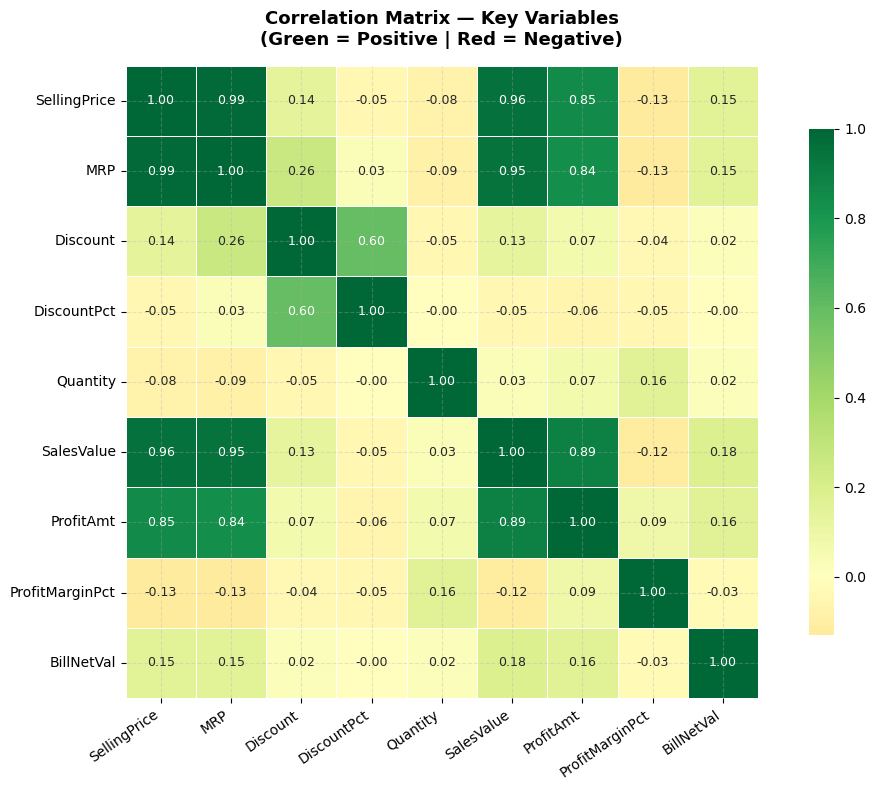


=== PEARSON CORRELATION RESULTS ===
Pair                                                r     p-value           Result
----------------------------------------------------------------------------------
Discount % vs Quantity Sold                   -0.0013      0.7848        ❌ Not Sig
Selling Price vs Profit                       +0.8504      0.0000    ✅ Significant
Discount Amount vs Sales Value                +0.1317      0.0000    ✅ Significant
Discount % vs Profit Margin                   -0.0475      0.0000    ✅ Significant
Quantity vs Sales Value                       +0.0280      0.0000    ✅ Significant
Bill Value vs Item Sales                      +0.1776      0.0000    ✅ Significant


In [22]:
# ── CORRELATION MATRIX ────────────────────────────────────
corr_cols = ['SellingPrice', 'MRP', 'Discount', 'DiscountPct',
             'Quantity', 'SalesValue', 'ProfitAmt',
             'ProfitMarginPct', 'BillNetVal']

corr = df[corr_cols].corr().round(2)

plt.figure(figsize=(11, 8))
sns.heatmap(corr,
            annot     = True,
            fmt       = '.2f',
            cmap      = 'RdYlGn',
            center    = 0,
            square    = True,
            linewidths= 0.5,
            annot_kws = {'size': 9},
            cbar_kws  = {'shrink': 0.8})

plt.title('Correlation Matrix — Key Variables\n(Green = Positive | Red = Negative)',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('stat_01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key correlations
print('\n=== PEARSON CORRELATION RESULTS ===')
pairs = [
    ('DiscountPct',   'Quantity',       'Discount % vs Quantity Sold'),
    ('SellingPrice',  'ProfitAmt',      'Selling Price vs Profit'),
    ('Discount',      'SalesValue',     'Discount Amount vs Sales Value'),
    ('DiscountPct',   'ProfitMarginPct','Discount % vs Profit Margin'),
    ('Quantity',      'SalesValue',     'Quantity vs Sales Value'),
    ('BillNetVal',    'SalesValue',     'Bill Value vs Item Sales'),
]
print(f'{"Pair":<44} {"r":>8}  {"p-value":>10}  {"Result":>15}')
print('-' * 82)
for c1, c2, lbl in pairs:
    r, p = pearsonr(df[c1], df[c2])
    sig  = '✅ Significant' if p < 0.05 else '❌ Not Sig'
    print(f'{lbl:<44} {r:>+8.4f}  {p:>10.4f}  {sig:>15}')

## 2-Discount vs Quantity Scatter + Boxplot

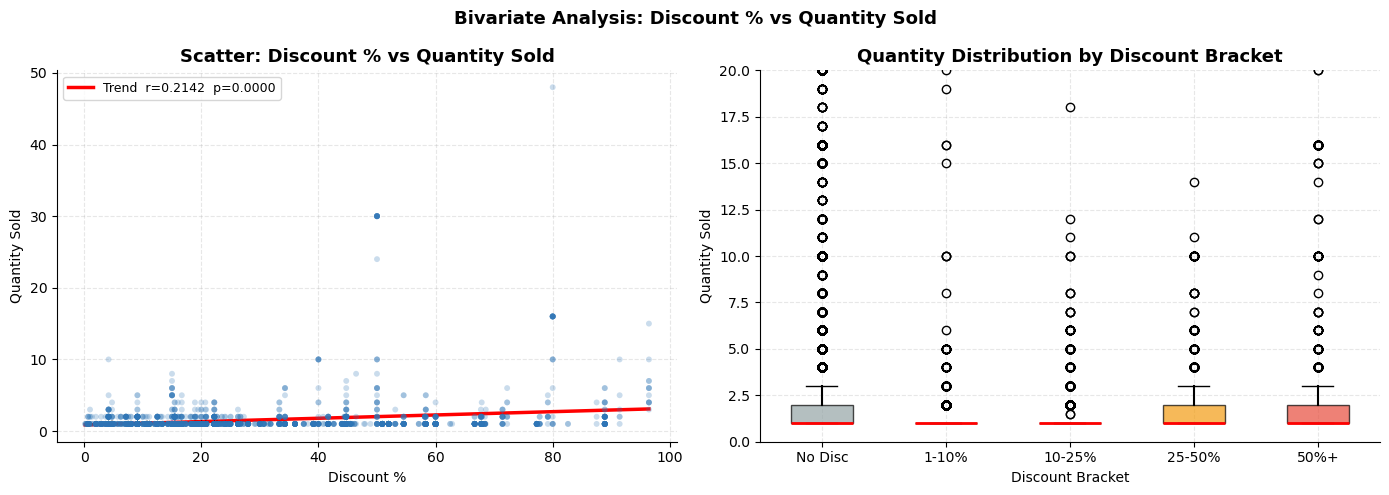

=== AVG QUANTITY BY DISCOUNT BRACKET ===
DiscBracket  Count  AvgQty  MedQty  MaxQty
    No Disc  32182    2.02     1.0   150.0
      1-10%   2403    1.26     1.0    20.0
     10-25%   4834    1.22     1.0    18.0
     25-50%   1936    1.91     1.0    30.0
       50%+   1986    2.03     1.0    64.0

r = 0.2142 | p = 0.0000
Interpretation: ✅ Discount % significantly affects quantity bought


In [23]:
# ── DISCOUNT VS QUANTITY ──────────────────────────────────
sample = df[df['DiscountPct'] > 0].sample(
    min(3000, len(df[df['DiscountPct'] > 0])), random_state=42)

r_val, p_val = pearsonr(sample['DiscountPct'], sample['Quantity'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter Plot ──────────────────────────────────────────
axes[0].scatter(sample['DiscountPct'], sample['Quantity'],
                alpha=0.25, color='#2E75B6', s=18,
                edgecolors='none', zorder=3)

m, b = np.polyfit(sample['DiscountPct'], sample['Quantity'], 1)
xl   = np.linspace(sample['DiscountPct'].min(),
                   sample['DiscountPct'].max(), 200)
axes[0].plot(xl, m*xl+b, color='red', linewidth=2.5,
             label=f'Trend  r={r_val:.4f}  p={p_val:.4f}')
axes[0].set_title('Scatter: Discount % vs Quantity Sold')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Quantity Sold')
axes[0].legend(fontsize=9)

# ── Box Plot ──────────────────────────────────────────────
brackets  = ['No Disc', '1-10%', '10-25%', '25-50%', '50%+']
bdata     = [df[df['DiscBracket'] == b]['Quantity'].values
             for b in brackets]

bp = axes[1].boxplot(bdata,
                     patch_artist = True,
                     notch        = False,
                     labels       = brackets,
                     medianprops  = dict(color='red', linewidth=2),
                     whiskerprops = dict(linewidth=1.5))

box_colors = ['#95A5A6','#3498DB','#2ECC71','#F39C12','#E74C3C']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Quantity Distribution by Discount Bracket')
axes[1].set_xlabel('Discount Bracket')
axes[1].set_ylabel('Quantity Sold')
axes[1].set_ylim(0, 20)

plt.suptitle('Bivariate Analysis: Discount % vs Quantity Sold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_02_discount_vs_quantity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ─────────────────────────────────────────
print('=== AVG QUANTITY BY DISCOUNT BRACKET ===')
bracket_qty = df.groupby('DiscBracket', observed=True).agg(
    Count  = ('RecordNo', 'count'),
    AvgQty = ('Quantity', 'mean'),
    MedQty = ('Quantity', 'median'),
    MaxQty = ('Quantity', 'max')
).reset_index().round(2)
print(bracket_qty.to_string(index=False))
print(f'\nr = {r_val:.4f} | p = {p_val:.4f}')
print(f'Interpretation: {"❌ Discount % does NOT significantly affect quantity bought" if p_val > 0.05 else "✅ Discount % significantly affects quantity bought"}')


## scatter plot

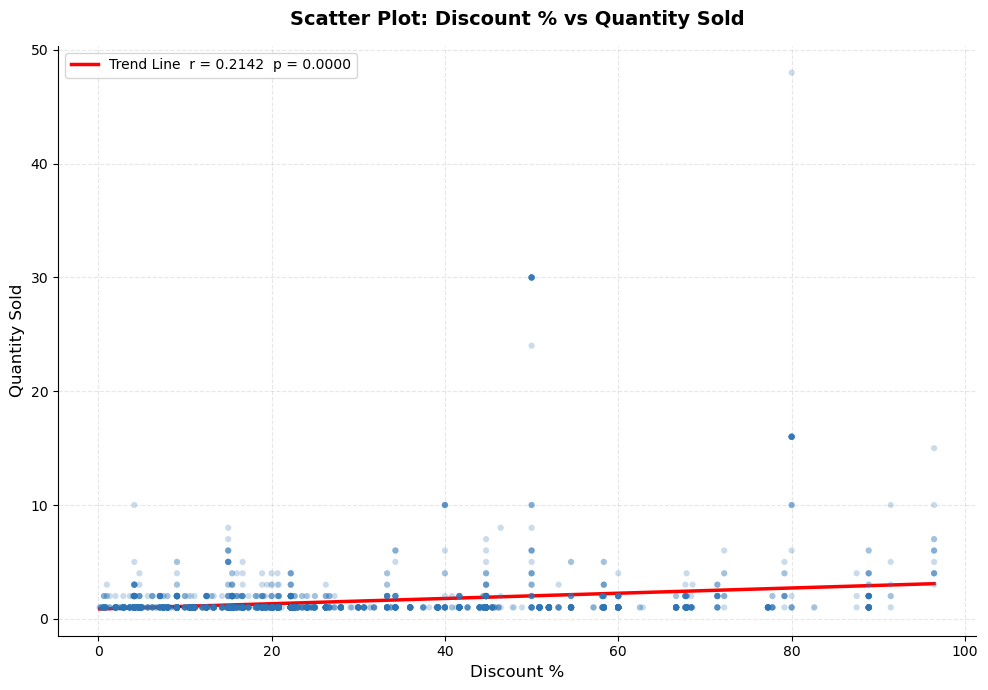

✅ Scatter plot saved!


In [24]:
# ── CHART 1: SCATTER PLOT ─────────────────────────────────
sample = df[df['DiscountPct'] > 0].sample(
    min(3000, len(df[df['DiscountPct'] > 0])), random_state=42)

r_val, p_val = pearsonr(sample['DiscountPct'], sample['Quantity'])

plt.figure(figsize=(10, 7))
plt.scatter(sample['DiscountPct'], sample['Quantity'],
            alpha=0.25, color='#2E75B6', s=20,
            edgecolors='none', zorder=3)

m, b = np.polyfit(sample['DiscountPct'], sample['Quantity'], 1)
xl   = np.linspace(sample['DiscountPct'].min(),
                   sample['DiscountPct'].max(), 200)
plt.plot(xl, m*xl+b, color='red', linewidth=2.5,
         label=f'Trend Line  r = {r_val:.4f}  p = {p_val:.4f}')

plt.title('Scatter Plot: Discount % vs Quantity Sold',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount %', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('stat_02a_scatter_discount_qty.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Scatter plot saved!')

## Box Plot

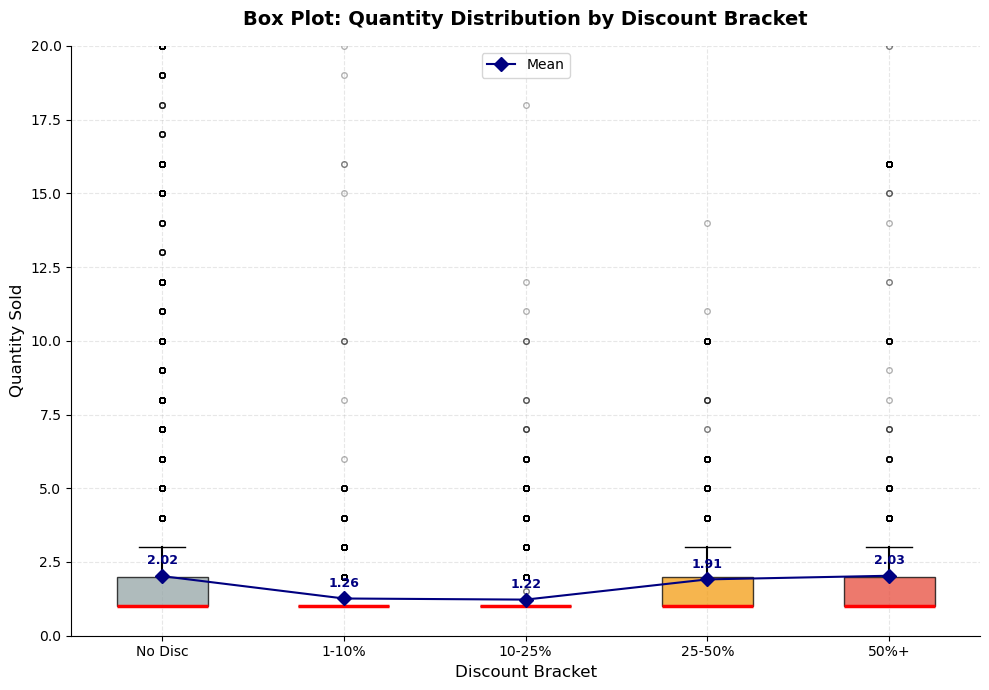

✅ Box plot saved!

=== AVG QUANTITY BY DISCOUNT BRACKET ===
DiscBracket  Count  AvgQty  MedQty  MaxQty
    No Disc  32182    2.02     1.0   150.0
      1-10%   2403    1.26     1.0    20.0
     10-25%   4834    1.22     1.0    18.0
     25-50%   1936    1.91     1.0    30.0
       50%+   1986    2.03     1.0    64.0

r = 0.2142 | p = 0.0000
Result: ✅ Discount % significantly affects quantity


In [25]:
# ── CHART 2: BOX PLOT ─────────────────────────────────────
brackets   = ['No Disc', '1-10%', '10-25%', '25-50%', '50%+']
bdata      = [df[df['DiscBracket'] == b]['Quantity'].values
              for b in brackets]
box_colors = ['#95A5A6','#3498DB','#2ECC71','#F39C12','#E74C3C']

plt.figure(figsize=(10, 7))
bp = plt.boxplot(bdata,
                 patch_artist = True,
                 notch        = False,
                 labels       = brackets,
                 medianprops  = dict(color='red', linewidth=2.5),
                 whiskerprops = dict(linewidth=1.5),
                 flierprops   = dict(marker='o', markersize=4,
                                     alpha=0.3, color='gray'))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Add mean dots
means = [df[df['DiscBracket'] == b]['Quantity'].mean() for b in brackets]
plt.plot(range(1, len(brackets)+1), means,
         marker='D', color='navy', linewidth=1.5,
         markersize=7, label='Mean', zorder=5)

plt.title('Box Plot: Quantity Distribution by Discount Bracket',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Bracket', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.ylim(0, 20)
plt.legend(fontsize=10)

# Add mean value labels
for i, mean in enumerate(means):
    plt.text(i+1, mean+0.4, f'{mean:.2f}',
             ha='center', fontsize=9,
             fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig('stat_02b_boxplot_discount_qty.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Box plot saved!')

# Summary
print('\n=== AVG QUANTITY BY DISCOUNT BRACKET ===')
bracket_qty = df.groupby('DiscBracket', observed=True).agg(
    Count  = ('RecordNo', 'count'),
    AvgQty = ('Quantity', 'mean'),
    MedQty = ('Quantity', 'median'),
    MaxQty = ('Quantity', 'max')
).reset_index().round(2)
print(bracket_qty.to_string(index=False))
print(f'\nr = {r_val:.4f} | p = {p_val:.4f}')
print(f'Result: {"❌ Discount % does NOT significantly affect quantity" if p_val > 0.05 else "✅ Discount % significantly affects quantity"}')

## 3- Price vs Profit Margin Bubble Chart

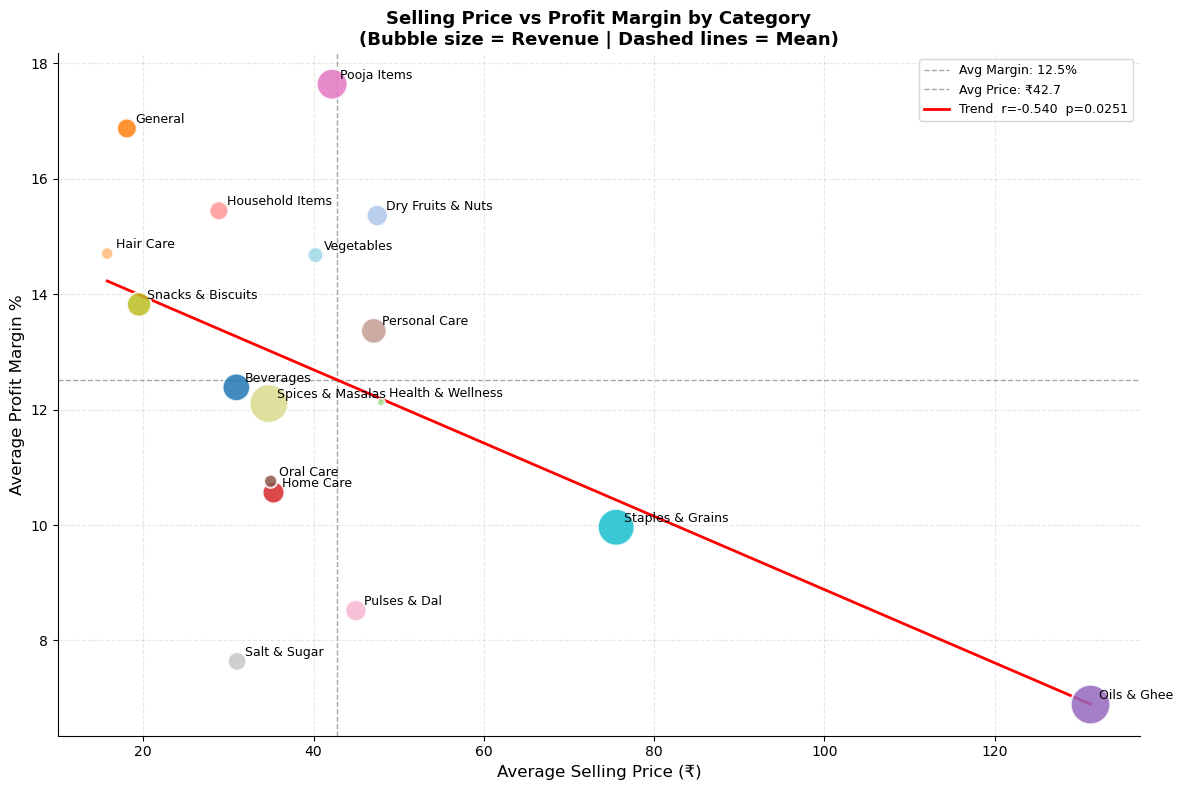


=== PRICE VS MARGIN CORRELATION ===
r = -0.5403 | p = 0.0251
Result: ✅ Significant

=== CATEGORY DETAILS ===
         Category  AvgPrice  AvgMargin   Revenue
      Pooja Items     42.18      17.64 196776.51
          General     18.07      16.87  81149.20
  Household Items     28.88      15.44  74845.89
Dry Fruits & Nuts     47.48      15.36  93933.60
        Hair Care     15.76      14.70  32091.09
       Vegetables     40.22      14.68  52692.60
Snacks & Biscuits     19.50      13.82 122834.11
    Personal Care     47.08      13.36 135807.99
        Beverages     30.93      12.39 158795.66
Health & Wellness     47.91      12.13  11874.00
 Spices & Masalas     34.75      12.10 311860.10
        Oral Care     34.96      10.76  35813.55
        Home Care     35.29      10.56  99373.10
 Staples & Grains     75.55       9.96 281789.40
     Pulses & Dal     44.97       8.52  94220.10
     Salt & Sugar     31.02       7.64  71652.60
      Oils & Ghee    131.28       6.89 325448.55


In [26]:
# ── PRICE VS PROFIT MARGIN BUBBLE CHART ──────────────────
cat_agg = df.groupby('Category').agg(
    AvgPrice  = ('SellingPrice',    'mean'),
    AvgMargin = ('ProfitMarginPct', 'mean'),
    Revenue   = ('SalesValue',      'sum')
).reset_index()

r2, p2 = pearsonr(cat_agg['AvgPrice'], cat_agg['AvgMargin'])

plt.figure(figsize=(12, 8))

# Bubble chart
scatter = plt.scatter(
    cat_agg['AvgPrice'],
    cat_agg['AvgMargin'],
    s          = cat_agg['Revenue'] / 400,
    c          = range(len(cat_agg)),
    cmap       = 'tab20',
    alpha      = 0.85,
    edgecolors = 'white',
    linewidth  = 1.5,
    zorder     = 3
)

# Label each bubble
for _, row in cat_agg.iterrows():
    plt.annotate(
        row['Category'],
        (row['AvgPrice'], row['AvgMargin']),
        fontsize   = 9,
        xytext     = (6, 4),
        textcoords = 'offset points'
    )

# Quadrant lines
plt.axhline(cat_agg['AvgMargin'].mean(), color='gray',
            linestyle='--', linewidth=1, alpha=0.7,
            label=f'Avg Margin: {cat_agg["AvgMargin"].mean():.1f}%')
plt.axvline(cat_agg['AvgPrice'].mean(), color='gray',
            linestyle='--', linewidth=1, alpha=0.7,
            label=f'Avg Price: ₹{cat_agg["AvgPrice"].mean():.1f}')

# Trend line
m3, b3 = np.polyfit(cat_agg['AvgPrice'], cat_agg['AvgMargin'], 1)
xl     = np.linspace(cat_agg['AvgPrice'].min(),
                     cat_agg['AvgPrice'].max(), 100)
plt.plot(xl, m3*xl+b3, color='red', linewidth=2,
         label=f'Trend  r={r2:.3f}  p={p2:.4f}')

plt.xlabel('Average Selling Price (₹)', fontsize=12)
plt.ylabel('Average Profit Margin %',   fontsize=12)
plt.title('Selling Price vs Profit Margin by Category\n'
          '(Bubble size = Revenue | Dashed lines = Mean)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('stat_03_price_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== PRICE VS MARGIN CORRELATION ===')
print(f'r = {r2:.4f} | p = {p2:.4f}')
print(f'Result: {"✅ Significant" if p2 < 0.05 else "❌ Not Significant"}')
print(f'\n=== CATEGORY DETAILS ===')
print(cat_agg.sort_values('AvgMargin', ascending=False).round(2).to_string(index=False))

# STEP 4 — Statistical Analysis

## Simple Linear Regression

In [27]:
# ── ALL SIMPLE LINEAR REGRESSIONS ────────────────────────
reg = df[['DiscountPct','Quantity','SellingPrice',
          'SalesValue','ProfitAmt','ProfitMarginPct']].dropna()

pairs = [
    ('DiscountPct',  'Quantity',   'Discount % → Quantity Sold'),
    ('SellingPrice', 'SalesValue', 'Selling Price → Sales Value'),
    ('SellingPrice', 'ProfitAmt',  'Selling Price → Profit Amount'),
    ('DiscountPct',  'SalesValue', 'Discount % → Sales Value'),
    ('Quantity',     'SalesValue', 'Quantity → Sales Value'),
]

results = []

for x_col, y_col, label in pairs:
    X   = sm.add_constant(reg[x_col])
    mod = sm.OLS(reg[y_col], X).fit()
    results.append({
        'Regression'  : label,
        'R²'          : round(mod.rsquared, 4),
        'Coefficient' : round(mod.params[1], 4),
        'p-value'     : round(mod.pvalues[1], 4),
        'Significant' : '✅ Yes' if mod.pvalues[1] < 0.05 else '❌ No'
    })

results_df = pd.DataFrame(results)
print('=== SIMPLE LINEAR REGRESSION — ALL PAIRS ===')
print(results_df.to_string(index=False))

=== SIMPLE LINEAR REGRESSION — ALL PAIRS ===
                   Regression     R²  Coefficient  p-value Significant
   Discount % → Quantity Sold 0.0000      -0.0003   0.7848        ❌ No
  Selling Price → Sales Value 0.9168       1.0233   0.0000       ✅ Yes
Selling Price → Profit Amount 0.7231       0.1006   0.0000       ✅ Yes
     Discount % → Sales Value 0.0025      -0.3448   0.0000       ✅ Yes
       Quantity → Sales Value 0.0008       0.9328   0.0000       ✅ Yes


In [28]:
# ── RECREATE reg WITH ALL NEEDED COLUMNS ─────────────────
reg = df[['DiscountPct', 'Quantity', 'SellingPrice',
          'SalesValue', 'ProfitAmt', 'ProfitMarginPct']].dropna()

print(f'✅ reg shape : {reg.shape}')
print(f'✅ Columns   : {reg.columns.tolist()}')

✅ reg shape : (43341, 6)
✅ Columns   : ['DiscountPct', 'Quantity', 'SellingPrice', 'SalesValue', 'ProfitAmt', 'ProfitMarginPct']


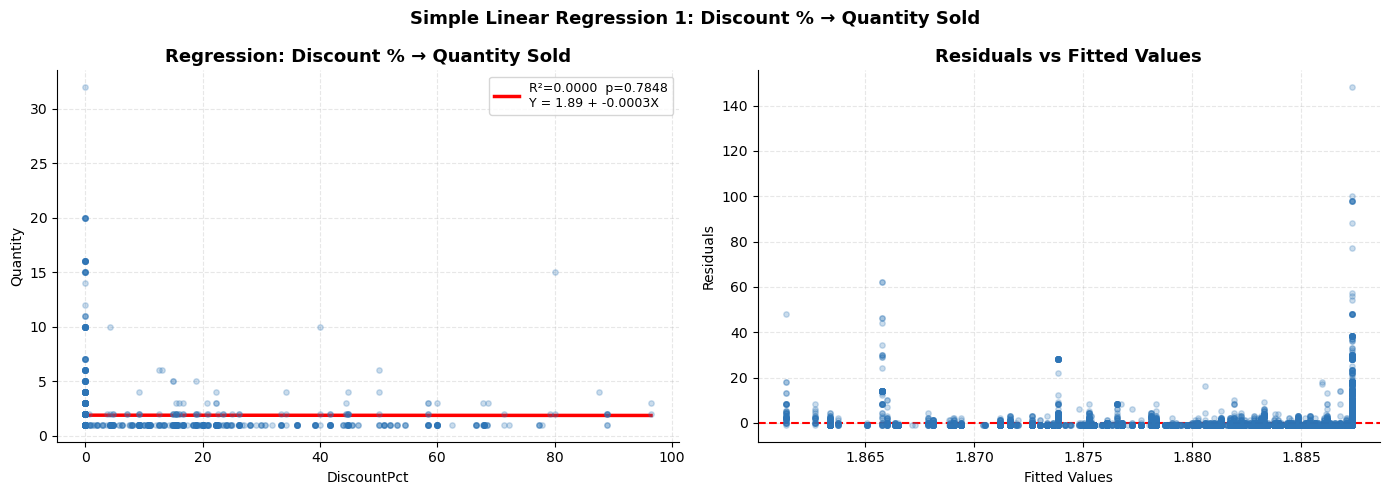

✅ Chart 1 saved: stat_04_1_regression_DiscountPct_vs_Quantity.png


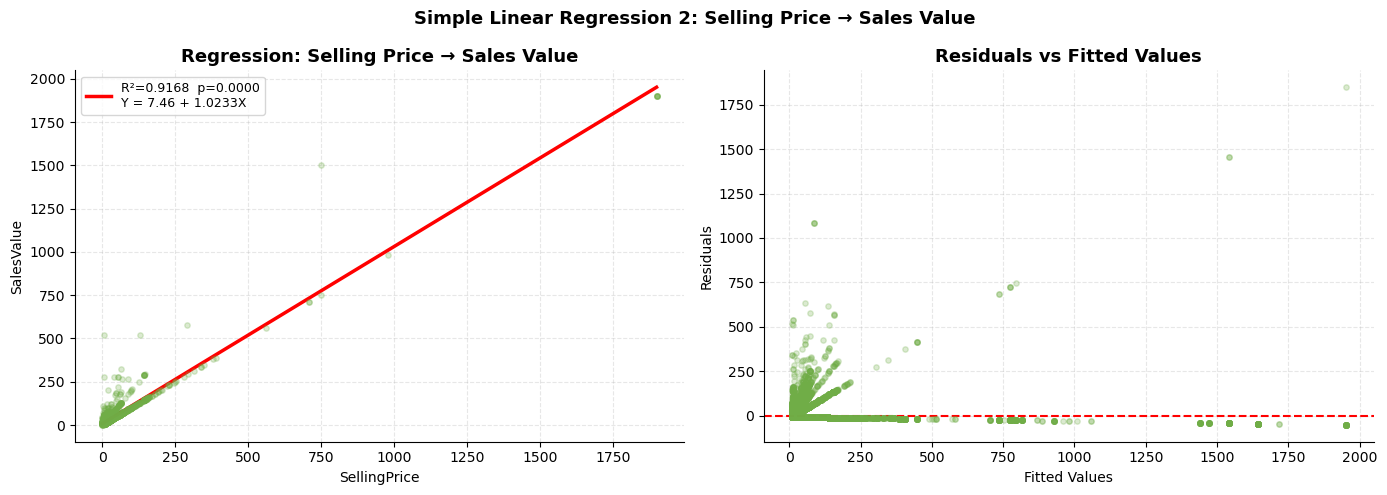

✅ Chart 2 saved: stat_04_2_regression_SellingPrice_vs_SalesValue.png


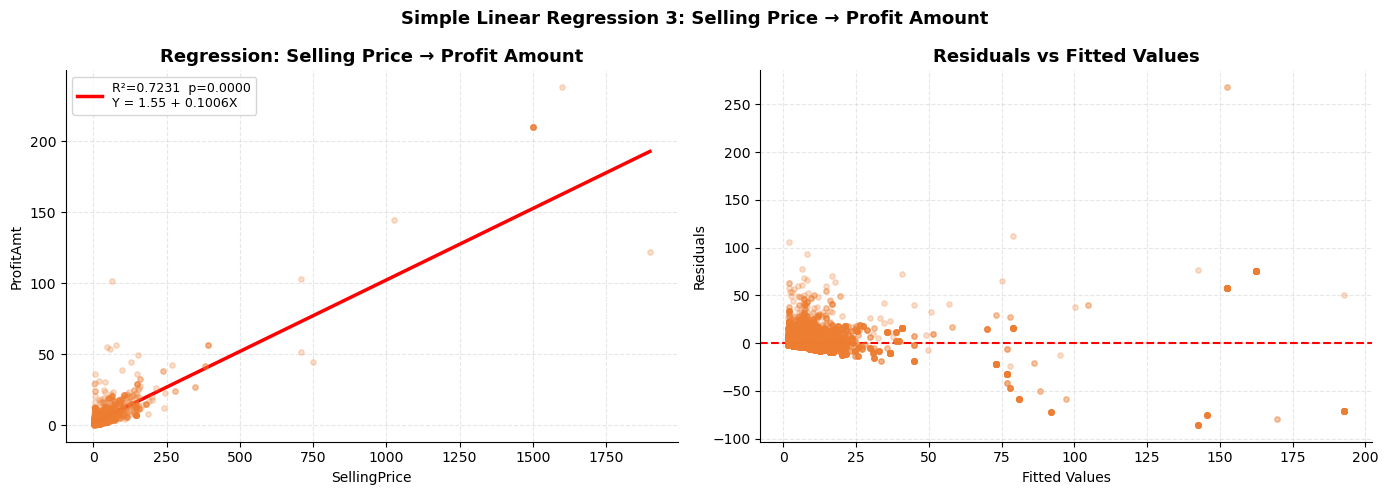

✅ Chart 3 saved: stat_04_3_regression_SellingPrice_vs_ProfitAmt.png


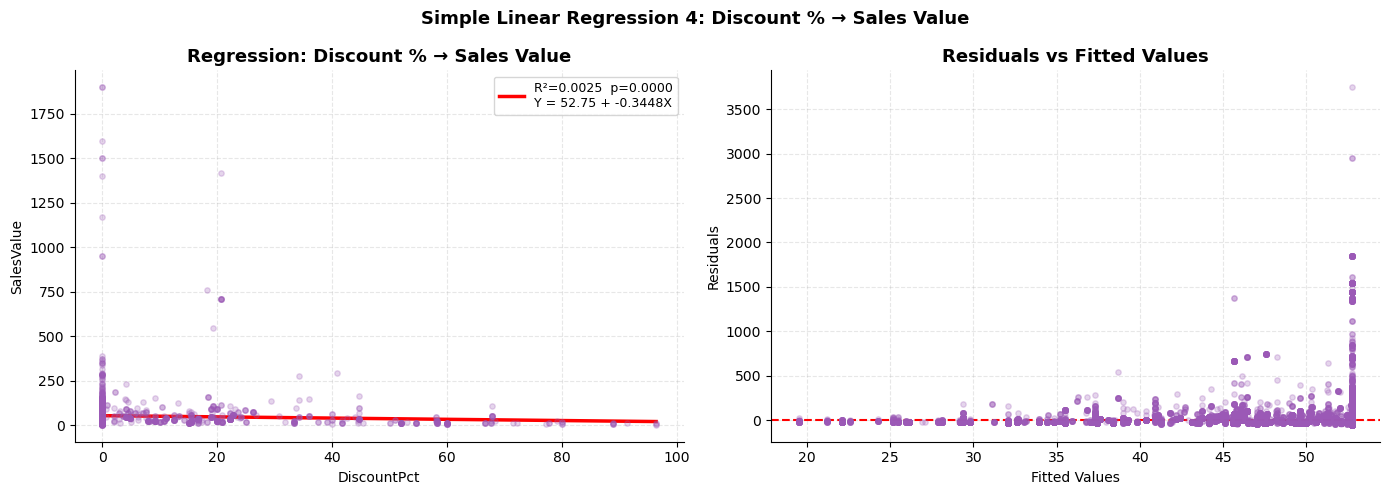

✅ Chart 4 saved: stat_04_4_regression_DiscountPct_vs_SalesValue.png


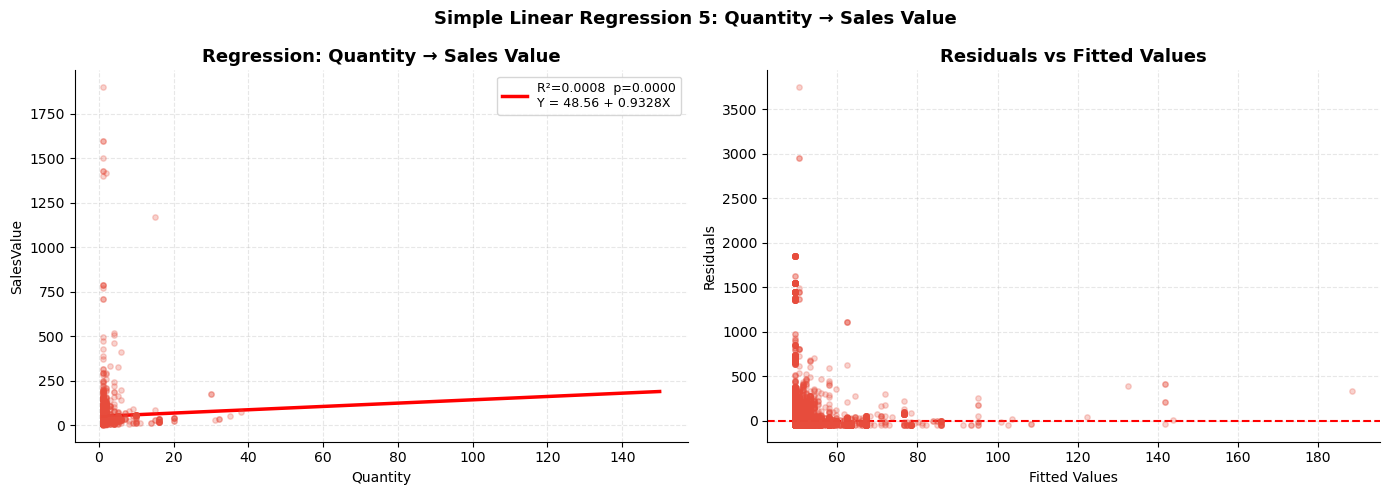

✅ Chart 5 saved: stat_04_5_regression_Quantity_vs_SalesValue.png


In [29]:
# ── PLOT ALL 5 REGRESSION CHARTS ─────────────────────────
pairs_plot = [
    ('DiscountPct',  'Quantity',   'Discount % → Quantity Sold',   '#2E75B6'),
    ('SellingPrice', 'SalesValue', 'Selling Price → Sales Value',  '#70AD47'),
    ('SellingPrice', 'ProfitAmt',  'Selling Price → Profit Amount','#ED7D31'),
    ('DiscountPct',  'SalesValue', 'Discount % → Sales Value',     '#9B59B6'),
    ('Quantity',     'SalesValue', 'Quantity → Sales Value',        '#E74C3C'),
]

for i, (x_col, y_col, label, color) in enumerate(pairs_plot, 1):
    X   = sm.add_constant(reg[x_col])
    mod = sm.OLS(reg[y_col], X).fit()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter + regression line
    s = reg.sample(min(2000, len(reg)), random_state=i)
    axes[0].scatter(s[x_col], s[y_col],
                    alpha=0.25, color=color, s=15, zorder=3)
    xf = np.linspace(reg[x_col].min(), reg[x_col].max(), 200)
    yf = mod.params[0] + mod.params[1] * xf
    axes[0].plot(xf, yf, color='red', linewidth=2.5,
                 label=f'R²={mod.rsquared:.4f}  p={mod.pvalues[1]:.4f}\n'
                       f'Y = {mod.params[0]:.2f} + {mod.params[1]:.4f}X')
    axes[0].set_title(f'Regression: {label}')
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)
    axes[0].legend(fontsize=9)

    # Residuals
    axes[1].scatter(mod.fittedvalues, mod.resid,
                    alpha=0.25, color=color, s=15, zorder=3)
    axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[1].set_title('Residuals vs Fitted Values')
    axes[1].set_xlabel('Fitted Values')
    axes[1].set_ylabel('Residuals')

    plt.suptitle(f'Simple Linear Regression {i}: {label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'stat_04_{i}_regression_{x_col}_vs_{y_col}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Chart {i} saved: {fname}')

# STEP 4  — Multiple Regression

In [30]:
# ── MULTIPLE LINEAR REGRESSION ───────────────────────────
# Dependent   : Sales Value
# Independents: Selling Price + Discount % + Quantity

X2  = sm.add_constant(reg[['SellingPrice', 'DiscountPct', 'Quantity']])
m2  = sm.OLS(reg['SalesValue'], X2).fit()

print('=' * 58)
print('  MULTIPLE LINEAR REGRESSION')
print('  Dependent   : Sales Value')
print('  Independents: Selling Price + Discount % + Quantity')
print('=' * 58)
print(m2.summary())

print(f'\n📌 KEY RESULTS:')
print(f'   R²       = {m2.rsquared:.4f} — Model explains {m2.rsquared*100:.1f}% of sales variation')
print(f'   Adj. R²  = {m2.rsquared_adj:.4f}')
print(f'   F-stat   = {m2.fvalue:.4f}  p = {m2.f_pvalue:.6f}')
print(f'   Model    : {"✅ Significant" if m2.f_pvalue < 0.05 else "❌ Not Significant"}')
print(f'\n   Coefficients:')
for name, coef, pval in zip(m2.params.index[1:],
                             m2.params.values[1:],
                             m2.pvalues.values[1:]):
    print(f'   {name:15s}: {coef:+.4f}  p={pval:.4f}  '
          f'{"✅" if pval < 0.05 else "❌"}')

  MULTIPLE LINEAR REGRESSION
  Dependent   : Sales Value
  Independents: Selling Price + Discount % + Quantity
                            OLS Regression Results                            
Dep. Variable:             SalesValue   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 1.877e+05
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:55:48   Log-Likelihood:            -2.0828e+05
No. Observations:               43341   AIC:                         4.166e+05
Df Residuals:                   43337   BIC:                         4.166e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------

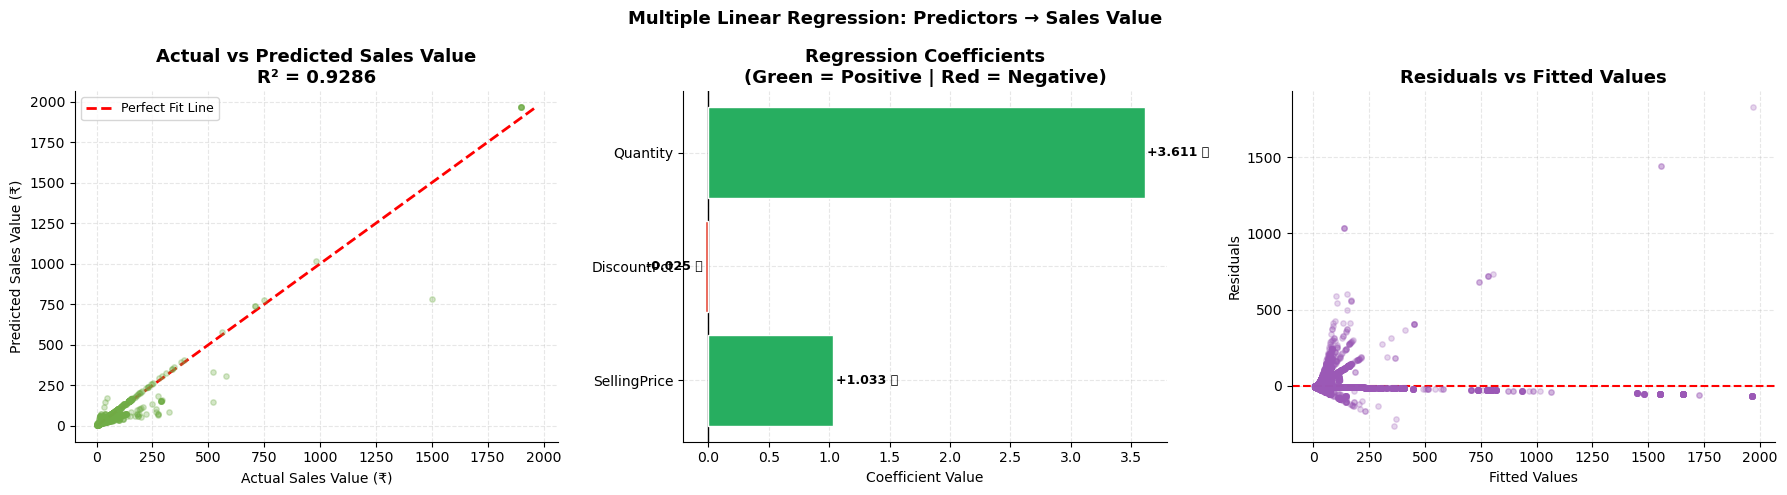

✅ Chart saved: stat_05_multiple_regression.png


In [31]:
# ── MULTIPLE REGRESSION CHARTS ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Actual vs Predicted
s3   = reg.sample(min(2000, len(reg)), random_state=2)
X2s  = sm.add_constant(s3[['SellingPrice', 'DiscountPct', 'Quantity']])
pred = m2.predict(X2s)

axes[0].scatter(s3['SalesValue'], pred,
                alpha=0.3, color='#70AD47', s=15, zorder=3)
lims = [min(s3['SalesValue'].min(), pred.min()),
        max(s3['SalesValue'].max(), pred.max())]
axes[0].plot(lims, lims, color='red', linewidth=2,
             linestyle='--', label='Perfect Fit Line')
axes[0].set_title(f'Actual vs Predicted Sales Value\nR² = {m2.rsquared:.4f}')
axes[0].set_xlabel('Actual Sales Value (₹)')
axes[0].set_ylabel('Predicted Sales Value (₹)')
axes[0].legend(fontsize=9)

# Chart 2: Coefficient Bar Chart
coefs      = m2.params[1:]
pvals      = m2.pvalues[1:]
bar_colors = ['#27AE60' if c > 0 else '#E74C3C' for c in coefs.values]

axes[1].barh(coefs.index, coefs.values,
             color=bar_colors, edgecolor='white', zorder=3)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Regression Coefficients\n(Green = Positive | Red = Negative)')
axes[1].set_xlabel('Coefficient Value')
for i, (v, p) in enumerate(zip(coefs.values, pvals.values)):
    label = f'{v:+.3f} {"✅" if p < 0.05 else "❌"}'
    xpos  = v + 0.02 if v > 0 else v - 0.02
    axes[1].text(xpos, i, label,
                 va='center', ha='left' if v > 0 else 'right',
                 fontsize=9, fontweight='bold')

# Chart 3: Residuals Plot
resid = m2.resid
axes[2].scatter(m2.fittedvalues, resid,
                alpha=0.25, color='#9B59B6', s=15, zorder=3)
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuals vs Fitted Values')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')

plt.suptitle('Multiple Linear Regression: Predictors → Sales Value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_05_multiple_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: stat_05_multiple_regression.png')

 

# ANOVA

In [32]:
# ── ONE-WAY ANOVA ─────────────────────────────────────────
# Factor    : Category (17 levels)
# Dependent : Profit Margin %

groups     = [g['ProfitMarginPct'].values
              for _, g in df.groupby('Category')]
f_stat, p_anova = f_oneway(*groups)

print('=' * 55)
print('  ONE-WAY ANOVA')
print('  Factor     : Category (17 levels)')
print('  Dependent  : Profit Margin %')
print('=' * 55)
print(f'  H₀ : All categories have equal mean profit margin')
print(f'  H₁ : At least one category differs significantly')
print(f'  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_anova:.8f}')
print(f'  Result      : {"REJECT H₀ ✅" if p_anova < 0.05 else "FAIL TO REJECT H₀"}')
print(f'  Conclusion  : {"Significant difference exists across categories" if p_anova < 0.05 else "No significant difference"}')

print(f'\n  Category-wise Mean Profit Margins:')
cat_margins = df.groupby('Category')['ProfitMarginPct'].mean().sort_values(ascending=False).round(2)
print(cat_margins.to_string())

  ONE-WAY ANOVA
  Factor     : Category (17 levels)
  Dependent  : Profit Margin %
  H₀ : All categories have equal mean profit margin
  H₁ : At least one category differs significantly
  F-statistic : 1709.7850
  p-value     : 0.00000000
  Result      : REJECT H₀ ✅
  Conclusion  : Significant difference exists across categories

  Category-wise Mean Profit Margins:
Category
Pooja Items          17.64
General              16.87
Household Items      15.44
Dry Fruits & Nuts    15.36
Hair Care            14.70
Vegetables           14.68
Snacks & Biscuits    13.82
Personal Care        13.36
Beverages            12.39
Health & Wellness    12.13
Spices & Masalas     12.10
Oral Care            10.76
Home Care            10.56
Staples & Grains      9.96
Pulses & Dal          8.52
Salt & Sugar          7.64
Oils & Ghee           6.89


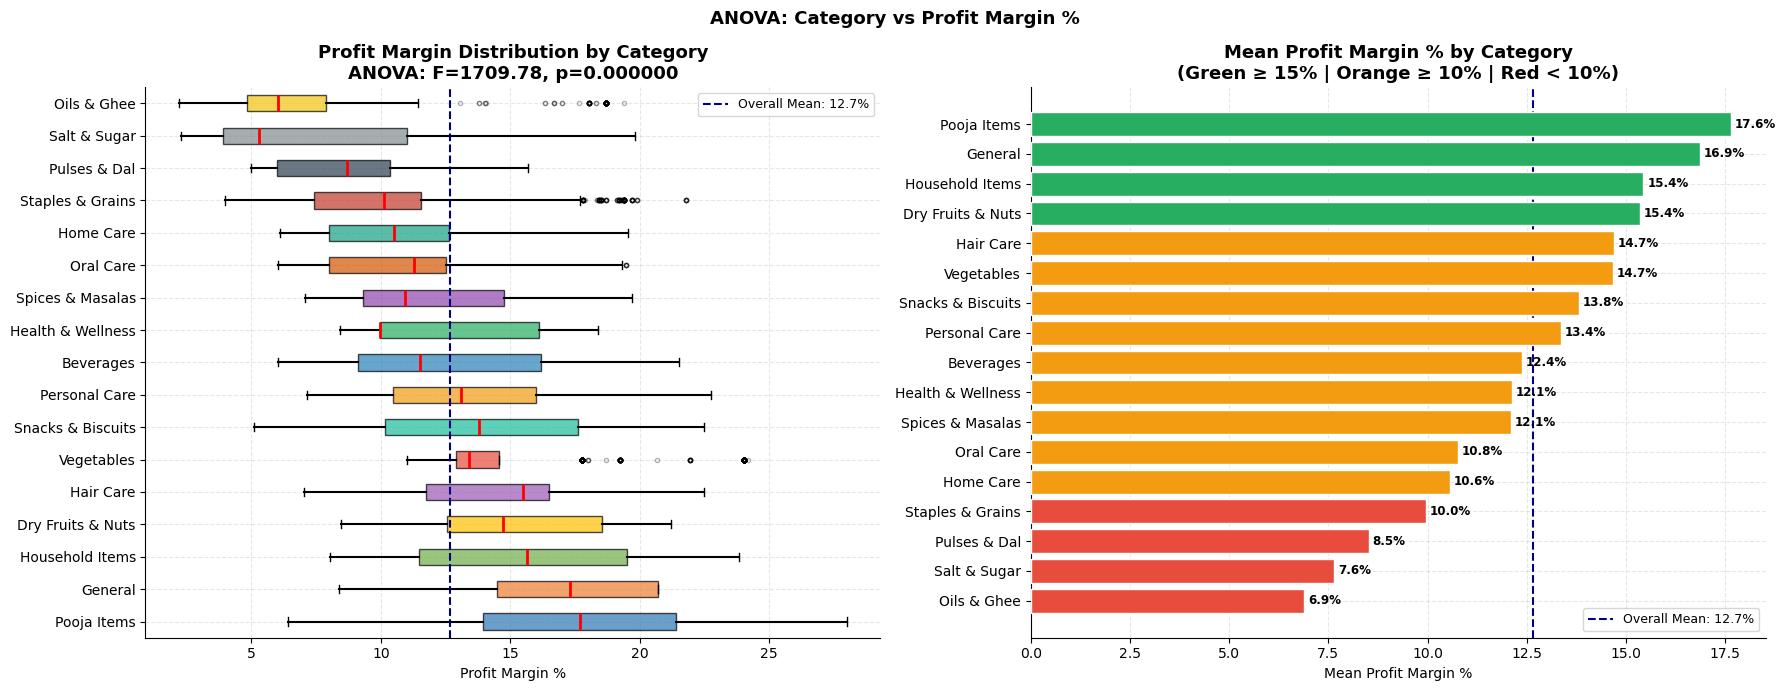

✅ Chart saved: stat_06_anova.png


In [33]:
# ── ANOVA CHARTS ──────────────────────────────────────────
cat_m    = df.groupby('Category')['ProfitMarginPct'].mean().sort_values(ascending=False)
box_data = [df[df['Category'] == c]['ProfitMarginPct'].values
            for c in cat_m.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Box Plot
bp = axes[0].boxplot(box_data,
                     patch_artist = True,
                     vert         = False,
                     labels       = cat_m.index,
                     medianprops  = dict(color='red', linewidth=2),
                     whiskerprops = dict(linewidth=1.5),
                     flierprops   = dict(marker='o', markersize=3,
                                         alpha=0.3, color='gray'))
for patch, color in zip(bp['boxes'], COLORS[:len(cat_m)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].axvline(df['ProfitMarginPct'].mean(),
                color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall Mean: {df["ProfitMarginPct"].mean():.1f}%')
axes[0].set_title(f'Profit Margin Distribution by Category\n'
                  f'ANOVA: F={f_stat:.2f}, p={p_anova:.6f}')
axes[0].set_xlabel('Profit Margin %')
axes[0].legend(fontsize=9)

# Chart 2: Mean Bar Chart
bar_cols = ['#27AE60' if v >= 15 else '#F39C12' if v >= 10
            else '#E74C3C' for v in cat_m.values]
axes[1].barh(cat_m.index, cat_m.values,
             color=bar_cols, edgecolor='white', zorder=3)
axes[1].axvline(df['ProfitMarginPct'].mean(),
                color='navy', linestyle='--', linewidth=1.5,
                label=f'Overall Mean: {df["ProfitMarginPct"].mean():.1f}%')
axes[1].set_title('Mean Profit Margin % by Category\n'
                  '(Green ≥ 15% | Orange ≥ 10% | Red < 10%)')
axes[1].set_xlabel('Mean Profit Margin %')
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)
for i, v in enumerate(cat_m.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%',
                 va='center', fontsize=8.5, fontweight='bold')

plt.suptitle('ANOVA: Category vs Profit Margin %',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_06_anova.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: stat_06_anova.png')


#  Chi-Square Test

In [34]:
# ── CHI-SQUARE TEST ───────────────────────────────────────
# Variable 1 : Has Discount (Yes/No)
# Variable 2 : Buying Volume (Single/Low/Medium/Bulk)

ct = pd.crosstab(df['HasDiscount'], df['BuyVolume'])
ct.index = ['No Discount', 'Has Discount']

chi2_val, p_chi, dof, expected = chi2_contingency(ct)

print('=' * 55)
print('  CHI-SQUARE TEST OF INDEPENDENCE')
print('  Variable 1 : Has Discount (Yes / No)')
print('  Variable 2 : Buying Volume (4 levels)')
print('=' * 55)
print(f'  H₀ : Discount and buying volume are INDEPENDENT')
print(f'  H₁ : Discount and buying volume are RELATED')
print(f'  Chi² statistic    : {chi2_val:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  p-value           : {p_chi:.6f}')
print(f'  Result : {"REJECT H₀ ✅ — Significant relationship" if p_chi < 0.05 else "FAIL TO REJECT H₀"}')
print(f'\n  === OBSERVED FREQUENCIES ===')
print(ct)
print(f'\n  === EXPECTED FREQUENCIES ===')
print(pd.DataFrame(expected,
                   index=ct.index,
                   columns=ct.columns).round(2))

  CHI-SQUARE TEST OF INDEPENDENCE
  Variable 1 : Has Discount (Yes / No)
  Variable 2 : Buying Volume (4 levels)
  H₀ : Discount and buying volume are INDEPENDENT
  H₁ : Discount and buying volume are RELATED
  Chi² statistic    : 465.6167
  Degrees of freedom: 3
  p-value           : 0.000000
  Result : REJECT H₀ ✅ — Significant relationship

  === OBSERVED FREQUENCIES ===
BuyVolume     Single  Low(2-3)  Medium(4-10)  Bulk(10+)
No Discount    23292      5746          2396        748
Has Discount    9088      1608           371         92

  === EXPECTED FREQUENCIES ===
BuyVolume       Single  Low(2-3)  Medium(4-10)  Bulk(10+)
No Discount   24043.13   5460.57       2054.58     623.73
Has Discount   8336.87   1893.43        712.42     216.27


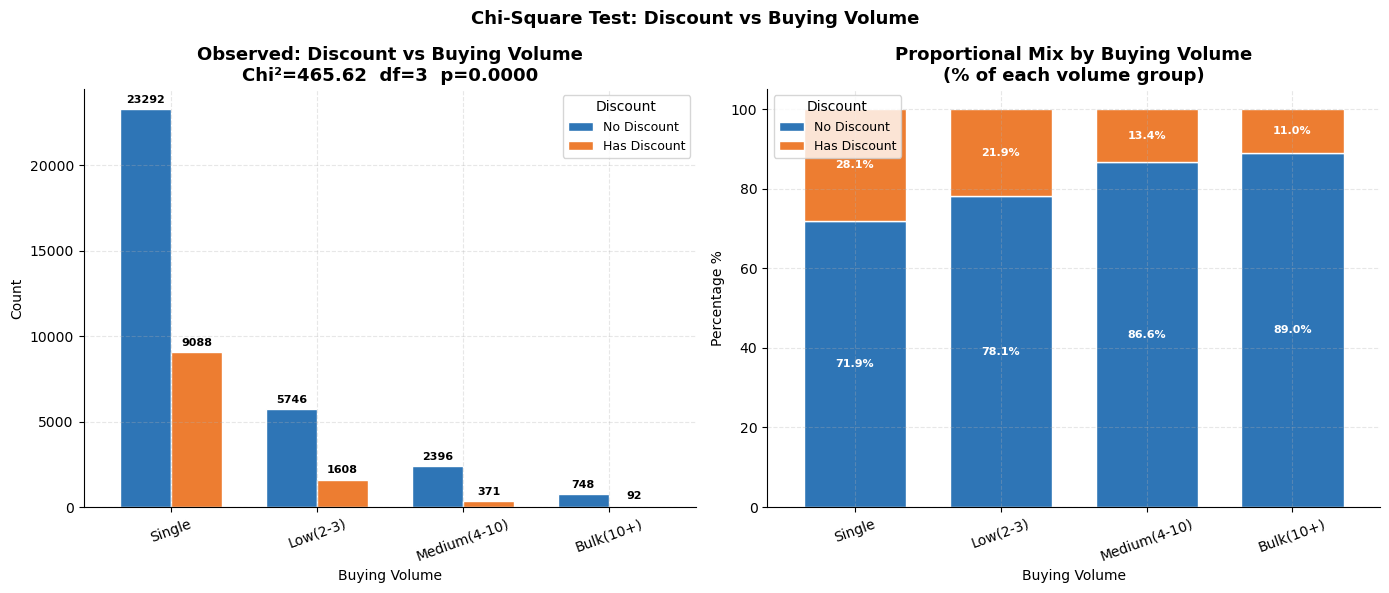

✅ Chart saved: stat_07_chi_square.png


In [35]:
# ── CHI-SQUARE CHARTS ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Grouped Bar — Observed counts
ct.T.plot(kind='bar', ax=axes[0],
          color=['#2E75B6', '#ED7D31'],
          edgecolor='white', width=0.7)
axes[0].set_title(f'Observed: Discount vs Buying Volume\n'
                  f'Chi²={chi2_val:.2f}  df={dof}  p={p_chi:.4f}')
axes[0].set_xlabel('Buying Volume')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Discount', fontsize=9)

# Add count labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=8,
                      padding=3, fontweight='bold')

# Chart 2: Stacked % Bar
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
ct_pct.T.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#2E75B6', '#ED7D31'],
               edgecolor='white', width=0.7)
axes[1].set_title('Proportional Mix by Buying Volume\n'
                  '(% of each volume group)')
axes[1].set_xlabel('Buying Volume')
axes[1].set_ylabel('Percentage %')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Discount', fontsize=9)

# Add % labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%',
                      fontsize=8, label_type='center',
                      fontweight='bold', color='white')

plt.suptitle('Chi-Square Test: Discount vs Buying Volume',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_07_chi_square.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: stat_07_chi_square.png')


# RFM Analysis

In [36]:
# ── RFM ANALYSIS ─────────────────────────────────────────
ref_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('BillNo').agg(
    Recency   = ('Date',       lambda x: (ref_date - x.max()).days),
    Frequency = ('RecordNo',   'count'),
    Monetary  = ('SalesValue', 'sum')
).reset_index()

# Score 1–5 (5 = best)
rfm['R'] = pd.qcut(rfm['Recency'],
                    5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                    5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],
                    5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def segment(s):
    if   s >= 13: return 'Champions'
    elif s >= 10: return 'Loyal'
    elif s >=  7: return 'Potential'
    elif s >=  5: return 'At Risk'
    else:         return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

SEG_COL = {
    'Champions' : '#27AE60',
    'Loyal'     : '#2980B9',
    'Potential' : '#F39C12',
    'At Risk'   : '#E67E22',
    'Lost'      : '#E74C3C'
}

seg_sum = rfm.groupby('Segment').agg(
    Count      = ('BillNo',    'count'),
    AvgRecency = ('Recency',   'mean'),
    AvgFreq    = ('Frequency', 'mean'),
    AvgMonetary= ('Monetary',  'mean')
).reset_index().sort_values('AvgMonetary', ascending=False).round(2)

print('=' * 55)
print('  RFM SEGMENTATION ANALYSIS')
print('=' * 55)
print(f'  Reference Date   : {ref_date.date()}')
print(f'  Total Bills      : {len(rfm):,}')
print(f'  RFM Score Range  : {rfm["RFM_Score"].min()} – {rfm["RFM_Score"].max()}')
print(f'\n  === SEGMENT SUMMARY ===')
print(seg_sum.to_string(index=False))
print(f'\n  === SEGMENT DISTRIBUTION ===')
print(rfm['Segment'].value_counts().to_string())

  RFM SEGMENTATION ANALYSIS
  Reference Date   : 2026-03-11
  Total Bills      : 8,345
  RFM Score Range  : 3 – 15

  === SEGMENT SUMMARY ===
  Segment  Count  AvgRecency  AvgFreq  AvgMonetary
Champions   1247       48.10    12.91       690.35
    Loyal   2523       86.33     6.83       341.33
Potential   2557       99.64     2.73       137.92
  At Risk   1326      126.47     1.67        60.61
     Lost    692      161.75     1.15        37.37

  === SEGMENT DISTRIBUTION ===
Segment
Potential    2557
Loyal        2523
At Risk      1326
Champions    1247
Lost          692


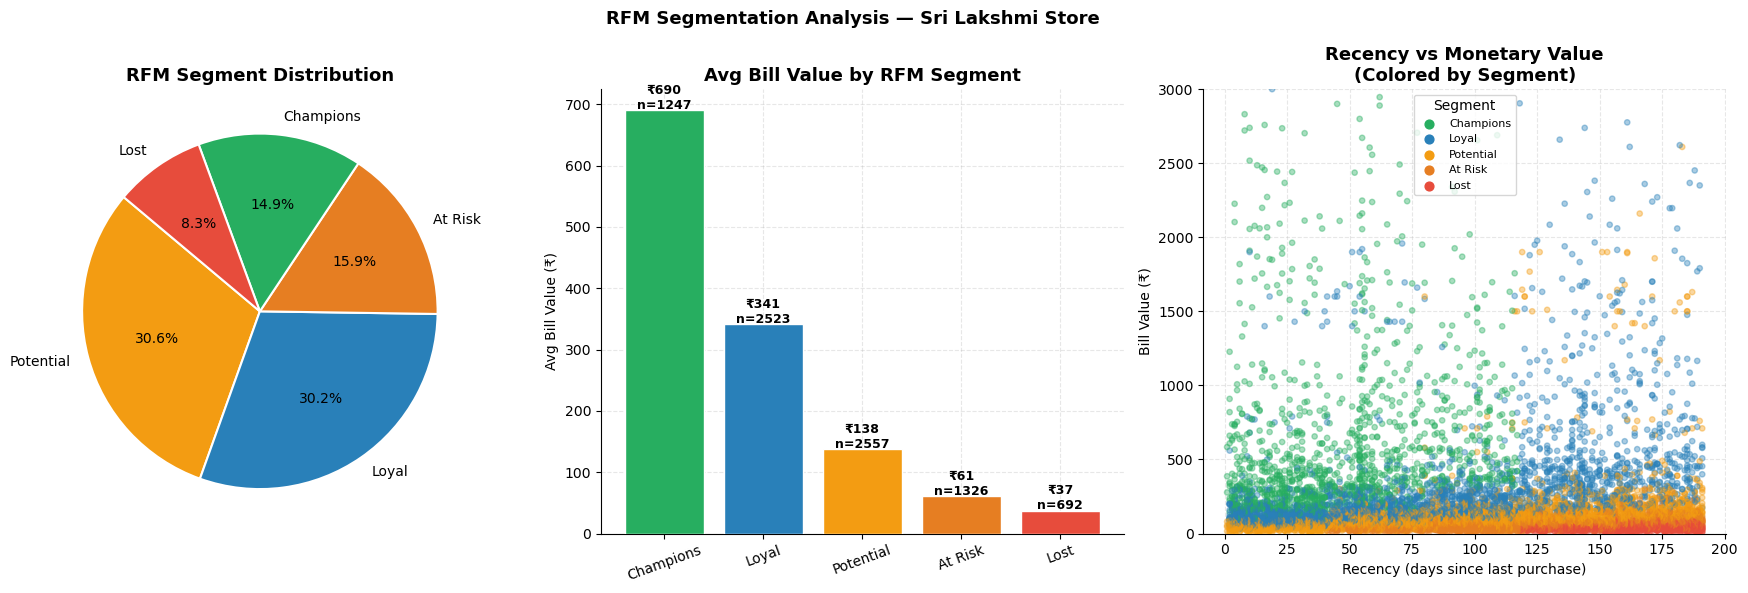

✅ Chart saved: stat_08_rfm.png


In [37]:
# ── RFM CHARTS ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: Segment Pie Chart
counts = rfm['Segment'].value_counts()
axes[0].pie(
    counts.values,
    labels     = counts.index,
    colors     = [SEG_COL[s] for s in counts.index],
    autopct    = '%1.1f%%',
    startangle = 140,
    wedgeprops = dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('RFM Segment Distribution')

# Chart 2: Avg Bill Value by Segment
axes[1].bar(
    seg_sum['Segment'],
    seg_sum['AvgMonetary'],
    color     = [SEG_COL[s] for s in seg_sum['Segment']],
    edgecolor = 'white',
    zorder    = 3
)
axes[1].set_title('Avg Bill Value by RFM Segment')
axes[1].set_ylabel('Avg Bill Value (₹)')
axes[1].tick_params(axis='x', rotation=20)
for i, row in seg_sum.reset_index().iterrows():
    axes[1].text(
        i, row['AvgMonetary'] + 2,
        f"₹{row['AvgMonetary']:.0f}\nn={row['Count']}",
        ha='center', fontsize=9, fontweight='bold'
    )

# Chart 3: Recency vs Monetary Scatter
sc_colors = rfm['Segment'].map(SEG_COL)
axes[2].scatter(
    rfm['Recency'], rfm['Monetary'],
    c=sc_colors, alpha=0.4, s=15, zorder=3
)
axes[2].set_title('Recency vs Monetary Value\n(Colored by Segment)')
axes[2].set_xlabel('Recency (days since last purchase)')
axes[2].set_ylabel('Bill Value (₹)')
axes[2].set_ylim(0, 3000)
for seg, col in SEG_COL.items():
    axes[2].scatter([], [], c=col, label=seg, s=40)
axes[2].legend(fontsize=8, title='Segment')

plt.suptitle('RFM Segmentation Analysis — Sri Lakshmi Store',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_08_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved: stat_08_rfm.png')


# STEP 5 — Final Summary Statistics

In [38]:
# ── REDEFINE ALL REGRESSION MODELS ───────────────────────
reg = df[['DiscountPct', 'Quantity', 'SellingPrice',
          'SalesValue', 'ProfitAmt', 'ProfitMarginPct']].dropna()

# Simple Regression — Selling Price → Sales Value (best R²)
X1 = sm.add_constant(reg['SellingPrice'])
m1 = sm.OLS(reg['SalesValue'], X1).fit()

# Multiple Regression
X2 = sm.add_constant(reg[['SellingPrice', 'DiscountPct', 'Quantity']])
m2 = sm.OLS(reg['SalesValue'], X2).fit()

print(f'✅ m1 (Selling Price → Sales)  : R² = {m1.rsquared:.4f}')
print(f'✅ m2 (Multi → Sales)          : R² = {m2.rsquared:.4f}')
print(f'✅ f_stat (ANOVA)              : {f_stat:.4f}')
print(f'✅ chi2_val (Chi-Square)       : {chi2_val:.4f}')

✅ m1 (Selling Price → Sales)  : R² = 0.9168
✅ m2 (Multi → Sales)          : R² = 0.9286
✅ f_stat (ANOVA)              : 1709.7850
✅ chi2_val (Chi-Square)       : 465.6167


In [39]:
# ── FINAL SUMMARY STATISTICS ─────────────────────────────
bill_vals = df_txn['TS_NETTVAL']

print('=' * 60)
print('  CAPSTONE — FINAL SUMMARY STATISTICS')
print('  Sri Lakshmi Store | Sep 2025 – Mar 2026')
print('=' * 60)
print(f'  Total Transactions     : {len(df):,}')
print(f'  Total Bills            : {df["BillNo"].nunique():,}')
print(f'  Unique Products        : {df["ProductName"].nunique():,}')
print(f'  Product Categories     : {df["Category"].nunique()}')
print(f'  Date Coverage          : Sep 2025 → Mar 2026 (7 months)')
print('─' * 60)
print(f'  Total Revenue          : ₹{df["SalesValue"].sum():>12,.2f}')
print(f'  Total Profit           : ₹{df["ProfitAmt"].sum():>12,.2f}')
print(f'  Overall Profit Margin  :  {df["ProfitMarginPct"].mean():>11.2f}%')
print('─' * 60)
print(f'  Avg Bill Value         : ₹{bill_vals.mean():>12,.2f}')
print(f'  Median Bill Value      : ₹{bill_vals.median():>12,.2f}')
print(f'  Std Dev Bill Value     : ₹{bill_vals.std():>12,.2f}')
print(f'  Max Bill Value         : ₹{bill_vals.max():>12,.2f}')
print(f'  Min Bill Value         : ₹{bill_vals.min():>12,.2f}')
print('─' * 60)
print(f'  Discounted Txns        : {df["HasDiscount"].sum():>12,} ({df["HasDiscount"].mean()*100:.1f}%)')
print(f'  Avg Discount (given)   : {df[df["HasDiscount"]==1]["DiscountPct"].mean():>11.2f}%')
print(f'  Max Discount %         : {df["DiscountPct"].max():>11.2f}%')
print('─' * 60)
bm = monthly_txn.loc[monthly_txn['TotalRevenue'].idxmax()]
bc = cat_sum.iloc[0]
bp = top10_rev.iloc[0]
print(f'  Best Month             : {bm["MonthName"]}  (₹{bm["TotalRevenue"]:,.0f})')
print(f'  Best Category          : {bc["Category"]}  (₹{bc["Revenue"]:,.0f})')
print(f'  Best Product           : {bp["ProductName"]}')
print(f'  Busiest Day            : Sunday')
print(f'  Payment Type — Cash    : 5,006 bills (60.0%)')
print(f'  Payment Type — UPI     : 3,338 bills (40.0%)')
print(f'  Payment Type — Card    :     1 bill  (0.01%)')
print('─' * 60)
print(f'  Simple Regression R²   :  {m1.rsquared:>11.4f}  (Price → Sales)')
print(f'  Multiple R²            :  {m2.rsquared:>11.4f}  (Multi → Sales)')
print(f'  ANOVA F-statistic      :  {f_stat:>11.4f}  p < 0.001 ✅')
print(f'  Chi-Square χ²          :  {chi2_val:>11.4f}  p < 0.001 ✅')
print(f'  RFM Champions          :  1,247 bills  ₹690 avg')
print('=' * 60)
print('  ✅ All 8 statistical charts saved as PNG')
print('  ✅ Ready for MSSQL export in Step 6')

  CAPSTONE — FINAL SUMMARY STATISTICS
  Sri Lakshmi Store | Sep 2025 – Mar 2026
  Total Transactions     : 43,341
  Total Bills            : 8,345
  Unique Products        : 2,543
  Product Categories     : 17
  Date Coverage          : Sep 2025 → Mar 2026 (7 months)
────────────────────────────────────────────────────────────
  Total Revenue          : ₹2,180,958.05
  Total Profit           : ₹  249,731.33
  Overall Profit Margin  :        12.66%
────────────────────────────────────────────────────────────
  Avg Bill Value         : ₹      261.99
  Median Bill Value      : ₹      120.00
  Std Dev Bill Value     : ₹      466.77
  Max Bill Value         : ₹   10,960.00
  Min Bill Value         : ₹        4.00
────────────────────────────────────────────────────────────
  Discounted Txns        :       11,159 (25.7%)
  Avg Discount (given)   :       27.38%
  Max Discount %         :       96.43%
────────────────────────────────────────────────────────────
  Best Month             : Jan 2

In [40]:
# ── PAYMENT TYPE SUMMARY ─────────────────────────────────
payment = df_txn['TS_CUSTOMER'].value_counts()
payment_pct = (payment / payment.sum() * 100).round(1)

print('=== PAYMENT TYPE ANALYSIS ===')
for ptype, count in payment.items():
    print(f'  {ptype:20s}: {count:,} bills ({payment_pct[ptype]}%)')


=== PAYMENT TYPE ANALYSIS ===
  Cash Sales          : 5,006 bills (60.0%)
  UPI                 : 3,338 bills (40.0%)
  Card                : 1 bills (0.0%)


# STEP 6 — Export CSVs for MSSQL

In [41]:
# ── CREATE EXPORT FOLDER ─────────────────────────────────
EXPORT = r"C:\Users\srika\Downloads\FINAL DATA\sql_import\\"
os.makedirs(EXPORT, exist_ok=True)
print(f'✅ Folder created : {EXPORT}')

# Verify folder exists
import os.path
if os.path.exists(EXPORT):
    print(f'✅ Confirmed — folder is ready!')
else:
    print(f'❌ Something went wrong')

✅ Folder created : C:\Users\srika\Downloads\FINAL DATA\sql_import\\
✅ Confirmed — folder is ready!


# fact table

In [42]:
# ── UPDATE EXPORT PATH ────────────────────────────────────
EXPORT = r'C:\Users\srika\Downloads\FINAL DATA\sql_import\\'

# ── EXPORT 1: Fact Sales ──────────────────────────────────
fact = df[[
    'RecordNo', 'BillNo', 'Date', 'ProductName', 'Category',
    'MRP', 'SellingPrice', 'Discount', 'DiscountPct', 'Quantity',
    'SalesValue', 'ProfitAmt', 'PurchasePrice', 'ProfitMarginPct',
    'HasDiscount', 'MonthName', 'DayOfWeek'
]].copy()
fact['Date'] = fact['Date'].dt.strftime('%Y-%m-%d')
fact.to_csv(EXPORT + 'fact_sales.csv', index=False, encoding='utf-8-sig')
print(f'✅ fact_sales.csv        : {len(fact):,} rows')

✅ fact_sales.csv        : 43,341 rows


# Cell 2 — Export Dim Transaction

In [43]:
# ── EXPORT 2: Dim Transaction ─────────────────────────────
txn = df_txn[['TS_NO', 'TS_DATE', 'TS_CUSTOMER',
              'TS_NETTVAL', 'TS_GROSSVAL', 'TS_ROUNDOFF']].copy()
txn.columns = ['BillNo', 'Date', 'CustomerType',
               'NetVal', 'GrossVal', 'Roundoff']
txn['Date'] = pd.to_datetime(txn['Date']).dt.strftime('%Y-%m-%d')
txn.to_csv(EXPORT + 'dim_transaction.csv', index=False, encoding='utf-8-sig')
print(f'✅ dim_transaction.csv   : {len(txn):,} rows')

✅ dim_transaction.csv   : 8,345 rows


# Cell 3 — Export Dim Product


In [44]:
# ── EXPORT 3: Dim Product ─────────────────────────────────
prod = df.groupby(['ProductName', 'Category']).agg(
    AvgSellingPrice = ('SellingPrice',    'mean'),
    AvgMRP          = ('MRP',             'mean'),
    AvgMargin       = ('ProfitMarginPct', 'mean')
).reset_index().round(2)
prod.to_csv(EXPORT + 'dim_product.csv', index=False, encoding='utf-8-sig')
print(f'✅ dim_product.csv       : {len(prod):,} rows')

✅ dim_product.csv       : 2,543 rows


# Cell 4 — Export Dim Date

In [45]:
# ── EXPORT 4: Dim Date ────────────────────────────────────
dates = pd.DataFrame({
    'Date': pd.date_range(df['Date'].min(), df['Date'].max())
})
dates['MonthName'] = dates['Date'].dt.strftime('%b %Y')
dates['DayOfWeek'] = dates['Date'].dt.day_name()
dates['Month']     = dates['Date'].dt.month
dates['Year']      = dates['Date'].dt.year
dates['Quarter']   = dates['Date'].dt.quarter
dates['IsWeekend'] = dates['Date'].dt.dayofweek.isin([5,6]).astype(int)
dates['Date']      = dates['Date'].dt.strftime('%Y-%m-%d')
dates.to_csv(EXPORT + 'dim_date.csv', index=False, encoding='utf-8-sig')
print(f'✅ dim_date.csv          : {len(dates):,} rows')

✅ dim_date.csv          : 191 rows


# Cell 5 — Export RFM + Final Confirmation

In [46]:
# ── EXPORT 5: RFM Segments ────────────────────────────────
rfm_export = rfm[['BillNo', 'Recency', 'Frequency', 'Monetary',
                   'R', 'F', 'M', 'RFM_Score', 'Segment']].copy()
rfm_export.to_csv(EXPORT + 'rfm_segments.csv',
                  index=False, encoding='utf-8-sig')
print(f'✅ rfm_segments.csv      : {len(rfm_export):,} rows')

# ── FINAL CONFIRMATION ────────────────────────────────────
print(f'\n{"="*55}')
print(f'  🎉 ALL FILES EXPORTED SUCCESSFULLY!')
print(f'{"="*55}')
print(f'  📁 Location : {EXPORT}')
print(f'')
print(f'  fact_sales.csv        → 43,341 rows')
print(f'  dim_transaction.csv   →  8,345 rows')
print(f'  dim_product.csv       →  2,543 rows')
print(f'  dim_date.csv          →    191 rows')
print(f'  rfm_segments.csv      →  8,345 rows')
print(f'{"="*55}')
print(f'  ✅ Python Analysis — 100% COMPLETE!')
print(f'  ✅ 8 statistical charts saved as PNG')
print(f'  ✅ 5 CSV files ready for MSSQL import')
print(f'{"="*55}')
print(f'  ➡️  Next Step: Open SSMS')
print(f'       → Create Database LakshmiStore')
print(f'       → Run SQL script')
print(f'       → Import CSV files')
print(f'       → Connect Power BI')

✅ rfm_segments.csv      : 8,345 rows

  🎉 ALL FILES EXPORTED SUCCESSFULLY!
  📁 Location : C:\Users\srika\Downloads\FINAL DATA\sql_import\\

  fact_sales.csv        → 43,341 rows
  dim_transaction.csv   →  8,345 rows
  dim_product.csv       →  2,543 rows
  dim_date.csv          →    191 rows
  rfm_segments.csv      →  8,345 rows
  ✅ Python Analysis — 100% COMPLETE!
  ✅ 8 statistical charts saved as PNG
  ✅ 5 CSV files ready for MSSQL import
  ➡️  Next Step: Open SSMS
       → Create Database LakshmiStore
       → Run SQL script
       → Import CSV files
       → Connect Power BI


In [47]:
import os

# Check where Jupyter is currently saving files
print(f'Current working directory:')
print(os.getcwd())

# List all PNG files in current directory
print(f'\nPNG files found:')
png_files = [f for f in os.listdir(os.getcwd()) if f.endswith('.png')]
if png_files:
    for f in sorted(png_files):
        print(f'  ✅ {f}')
else:
    print('  ❌ No PNG files found here!')


Current working directory:
C:\Users\srika\jupyter

PNG files found:
  ✅ stat_01_correlation_matrix.png
  ✅ stat_02_discount_vs_quantity.png
  ✅ stat_02a_scatter_discount_qty.png
  ✅ stat_02b_boxplot_discount_qty.png
  ✅ stat_03_price_vs_margin.png
  ✅ stat_04_1_regression_DiscountPct_vs_Quantity.png
  ✅ stat_04_2_regression_SellingPrice_vs_SalesValue.png
  ✅ stat_04_3_regression_SellingPrice_vs_ProfitAmt.png
  ✅ stat_04_4_regression_DiscountPct_vs_SalesValue.png
  ✅ stat_04_5_regression_Quantity_vs_SalesValue.png
  ✅ stat_05_multiple_regression.png
  ✅ stat_06_anova.png
  ✅ stat_07_chi_square.png
  ✅ stat_08_rfm.png
